<a href="https://colab.research.google.com/github/FelipeT1/PS-2026.1/blob/main/Projeto_PS_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estimativa de Segurança das Linhas de Ônibus do Município do Rio de Janeiro

Processo Seletivo UFRJ Analytica 2026.1

Grupo O

Integrantes:

  DRE:

Felipe Teixeira Mello  DRE: 126030228

Sylvio Jorge Pastene Helt  DRE: 123675265

## Introdução

O objetivo do nosso trabalho foi tentar fazer uma estimativa da segurança de cada linha de ônibus do município do Rio de Janeiro, visando fornecer ao usuário uma informação importante para um eventual deslocamento pela cidade.

Usando dados da plataforma data.rio da Prefeitura do Rio, da do Instituto de Segurança pública e da api do Instituto Fogo Cruzado, fomos capazes de integrar informações sobre limites dos bairros, limites das CISPs (Circunscrições Integradas de Segurança Pública), traçado das linhas, violência armada e quantidade de roubos e furtos a coletivo em cada bairro.

O fluxo do trabalho envolveu fazer a importação dos dados para o notebook, seguida de uma visualização de seus principais atributos que permitiu também a verificação de inconsistências, eliminação de duplicatas e limpeza das bases de dados.

Prosseguimos com a criação de tabelas de equivalência entre as linhas de ônibus e os bairros/CISPs. Ou seja, duas tabelas nas quais uma coluna consiste nas linhas e a outra em bairros/CISPs atravessados.

Então, após transformar os dados para um formato adequado para a manipulação de séries temporais, realizamos uma regressão para estimar a quantidade das três informações analisadas (roubos/furtos a coletivo e tiroteios) nos próximos 30 dias. Nessa etapa, os dados foram divididos em treino e teste, e realizamos uma validação para descobrir qual o melhor estimador.

Com todas essas informações organizadas, foi possível desenvolver uma aplicação em (?) que permite buscar uma linha, visualizar seu trajeto, as estatísticas de recentes de violência agregadas e as previsões para o próximo mês. Além disso, criamos um score combinando os três índices para classificar o risco de uma linha como Baixo, Médio ou Alto.

### Bibliotecas e Configurações

É preciso importar bibliotecas e sincronizar o notebook com o repositório do Github no qual se encontram os dados. Esse processo é feito nas células abaixo.

In [1]:
!pip install adjustText

In [2]:
# Importação das bibliotecas usadas
import glob
import re
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import unicodedata
import time

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, ParameterSampler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import PoissonRegressor, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

from xgboost import XGBRegressor

from shapely.geometry import Point
from shapely import wkt
from adjustText import adjust_text

In [3]:
pd.set_option('display.float_format', '{:.4f}'.format)

In [4]:
!git clone https://github.com/FelipeT1/PS-2026.1.git

fatal: destination path 'PS-2026.1' already exists and is not an empty directory.


In [5]:
# Change to the cloned repository directory
os.chdir('/content/PS-2026.1')

# Now, execute git pull
!git pull

# Change back to the original content directory if needed for subsequent cells
os.chdir('/content')

Already up to date.


## Coleta e Limpeza dos dos dados

### Importando dados das linhas de ônibus

Obtivemos os dados com os trajetos das linhas de ônibus da cidade do Rio de Janeiro a partir [deste dataset](https://www.data.rio/datasets/PCRJ::itiner%C3%A1rios-de-servi%C3%A7os-de-%C3%B4nibus-regulares/explore) do data.rio. Utilizando a biblioteca geoPandas, importamos ele para esse notebook.

In [6]:
itinerarios_df = gpd.read_file("/content/PS-2026.1/data/dataRio/itinerarios.geojson")
itinerarios_df.head()

,fid,extensao,consorcio,descricao_desvio,tipo_rota,shape_id,direcao,destino,servico,SHAPE__Length,tipo_dia,geometry
0,1,24049,Intersul,None,regular,006j,0,Circular,LECD130,24049.6496,U,"LINESTRING (-43.21185 -22.89916, -43.21207 -22..."
1,2,8502,Santa Cruz,None,regular,01gk,1,Jardim Bangu,819,8502.5474,U,"LINESTRING (-43.46371 -22.87638, -43.46372 -22..."
2,3,12723,Intersul,None,regular,01o6,0,Circular,010,12723.3225,U,"LINESTRING (-43.18829 -22.91698, -43.18829 -22..."
3,4,29403,Internorte,None,regular,01vm,0,Copacabana,SN457,29403.6120,U,"LINESTRING (-43.30054 -22.88574, -43.30065 -22..."
4,5,25967,Santa Cruz,None,regular,040z,1,Terminal Campo Grande,857,25967.9521,U,"LINESTRING (-43.64759 -22.96519, -43.64759 -22..."


Vamos visualizar os dados importados sobre as coordenadas geográficas da cidade do Rio de Janeiro:

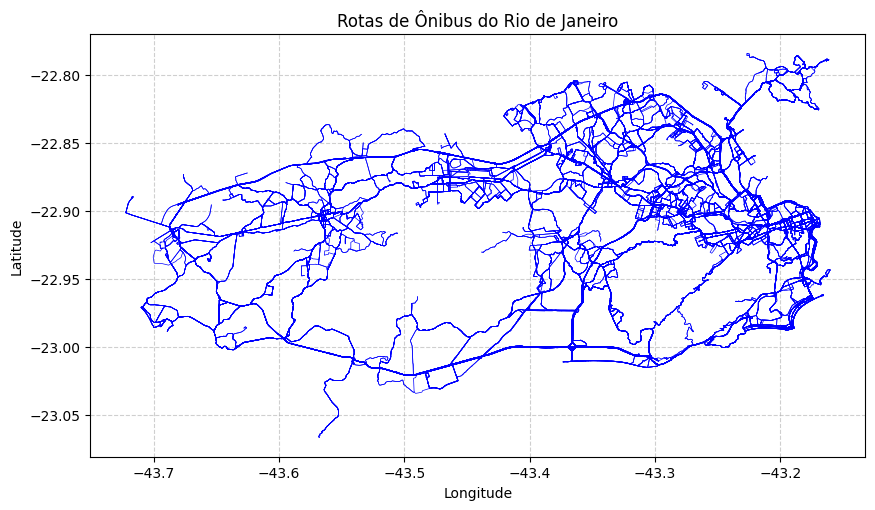

In [7]:
plt.figure(figsize=(10, 10))
itinerarios_df.plot(ax=plt.gca(), color='blue', linewidth=0.5)
plt.title('Rotas de Ônibus do Rio de Janeiro')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Vamos agora verificar a integridade dos dados importados:

In [8]:
print("--- Informações de itinerarios_df ---")
itinerarios_df.info()

--- Informações de itinerarios_df ---
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   fid               953 non-null    int32   
 1   extensao          953 non-null    int32   
 2   consorcio         953 non-null    object  
 3   descricao_desvio  0 non-null      object  
 4   tipo_rota         953 non-null    object  
 5   shape_id          953 non-null    object  
 6   direcao           953 non-null    object  
 7   destino           953 non-null    object  
 8   servico           953 non-null    object  
 9   SHAPE__Length     953 non-null    float64 
 10  tipo_dia          953 non-null    object  
 11  geometry          953 non-null    geometry
dtypes: float64(1), geometry(1), int32(2), object(8)
memory usage: 82.0+ KB


Temos 953 registros de linhas de ônibus. No entanto, temos apenas 491 valores únicos para serviço, que representa as linhas. Investigando, descobrimos que há linhas com 2, 3, 4 ou 5 trajetos diferentes. Para linhas com 2 trajetos diferentes eles referem-se aos trajetos de ida e volta. Nos demais casos são variações em dias da semana nos quais uma rua fica fechada, por exemplo. Por simplicidade, vamos remover as duplicatas, selecionando o primeiro trajeto de uma linha a aparecer no dataframe.

In [9]:
itinerarios_df.nunique()

,0
fid,953
extensao,921
consorcio,5
descricao_desvio,0
tipo_rota,3
shape_id,953
direcao,2
destino,190
servico,491
SHAPE__Length,943


In [10]:
itinerarios_df['servico'].value_counts()[lambda x: x > 2]

,count
servico,
2335,5
2338,5
42,4
17,4
60,4
22,4
80,4
51,4
35,4


In [11]:
print(f"Número de linhas antes de remover duplicatas: {len(itinerarios_df)}")
itinerarios_df = itinerarios_df.drop_duplicates(subset=['servico'], keep='first')
print(f"Número de linhas após remover duplicatas: {len(itinerarios_df)}")
itinerarios_df.head()

Número de linhas antes de remover duplicatas: 953
Número de linhas após remover duplicatas: 491


,fid,extensao,consorcio,descricao_desvio,tipo_rota,shape_id,direcao,destino,servico,SHAPE__Length,tipo_dia,geometry
0,1,24049,Intersul,None,regular,006j,0,Circular,LECD130,24049.6496,U,"LINESTRING (-43.21185 -22.89916, -43.21207 -22..."
1,2,8502,Santa Cruz,None,regular,01gk,1,Jardim Bangu,819,8502.5474,U,"LINESTRING (-43.46371 -22.87638, -43.46372 -22..."
2,3,12723,Intersul,None,regular,01o6,0,Circular,010,12723.3225,U,"LINESTRING (-43.18829 -22.91698, -43.18829 -22..."
3,4,29403,Internorte,None,regular,01vm,0,Copacabana,SN457,29403.6120,U,"LINESTRING (-43.30054 -22.88574, -43.30065 -22..."
4,5,25967,Santa Cruz,None,regular,040z,1,Terminal Campo Grande,857,25967.9521,U,"LINESTRING (-43.64759 -22.96519, -43.64759 -22..."


In [12]:
itinerarios_df.isnull().sum()

,0
fid,0
extensao,0
consorcio,0
descricao_desvio,491
tipo_rota,0
shape_id,0
direcao,0
destino,0
servico,0
SHAPE__Length,0


Também podemos descrever os dados numércios em em termos estatíticos, o que é útil apenas para a entender extensão das linhas.

In [13]:
itinerarios_df.describe()

,fid,extensao,SHAPE__Length
count,491.0000,491.0000,491.0000
mean,348.4338,25418.1894,25418.6862
std,239.2985,12995.6880,12995.6907
min,1.0000,2669.0000,2669.7877
25%,139.5000,16975.5000,16975.9764
50%,322.0000,24211.0000,24211.3726
75%,527.5000,30716.5000,30716.9337
max,936.0000,79272.0000,79272.5787


Por último, vamos analisar a extensão das rotas de ônibus e procurar por outliers, que não ocorrem. No geral, os dados parecem estar limpos e bem categorizados.

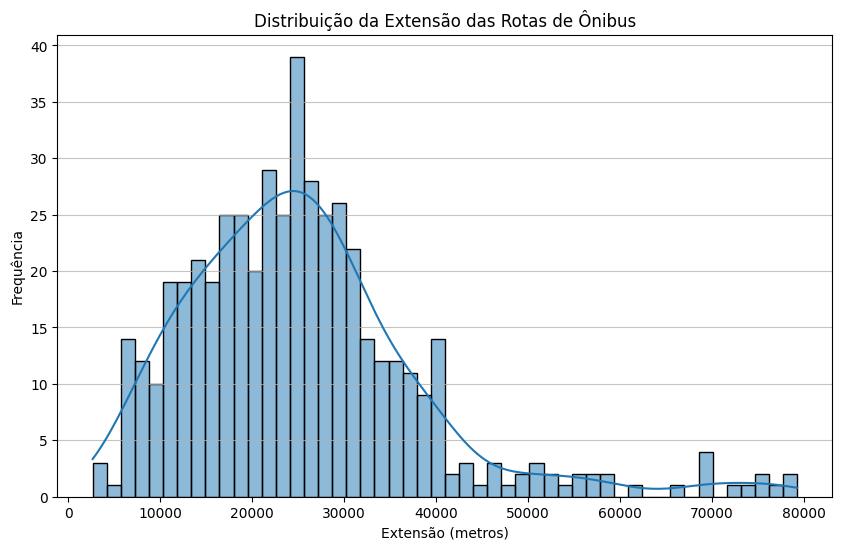

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(itinerarios_df['extensao'], bins=50, kde=True)
plt.title('Distribuição da Extensão das Rotas de Ônibus')
plt.xlabel('Extensão (metros)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Importando dados das CISPs

Os dados relativos à segurança fornecidos pelo Instituto de Segurança Pública do Governo do Estado do Rio de Janeiro são forneceidos por áreas denomiadas CISP (Circunscrições Integradas de Segurança Pública).

Os limites das CISPs estão disponíveis [nesse link.](https://www.ispdados.rj.gov.br/Conteudo.html) Iremos importar os limites dentro do município do Rio de Janeiro visando investigar quais linhas passam pelas CISPs com maior ocorrência de roubo a coletivo.

In [15]:
cisp_df = gpd.read_file('/content/PS-2026.1/data/isp/limiteCisp/lm_cisp_bd.dbf')
cisp_df.head()

,cisp,aisp,shape_Leng,shape_Area,AREA_GEO,geometry
0,120,35,1.5954,0.0823,937547313.1840,"POLYGON ((-42.18687 -22.55548, -42.18733 -22.5..."
1,127,25,0.6975,0.0062,70278058.8222,"MULTIPOLYGON (((-41.90082 -22.78264, -41.90079..."
2,151,11,1.7529,0.0818,933414484.9730,"POLYGON ((-42.52555 -22.16087, -42.5006 -22.18..."
3,107,38,1.2097,0.0508,580523881.4050,"POLYGON ((-43.34665 -22.00375, -43.34603 -22.0..."
4,123,32,2.1189,0.1066,1216847104.4100,"MULTIPOLYGON (((-41.97224 -22.1428, -41.97201 ..."


Verificamos que há 137 entradas, que correspondem às 137 CISPs [dessa tabela](https://www.ispdados.rj.gov.br/Arquivos/Relacao_RISPxAISPxCISP.pdf).

In [16]:
cisp_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   cisp        137 non-null    int64   
 1   aisp        137 non-null    int64   
 2   shape_Leng  137 non-null    float64 
 3   shape_Area  137 non-null    float64 
 4   AREA_GEO    137 non-null    float64 
 5   geometry    137 non-null    geometry
dtypes: float64(3), geometry(1), int64(2)
memory usage: 6.6 KB


Podemos também plotar geograficamente os dados importados para verificar sua acuidade

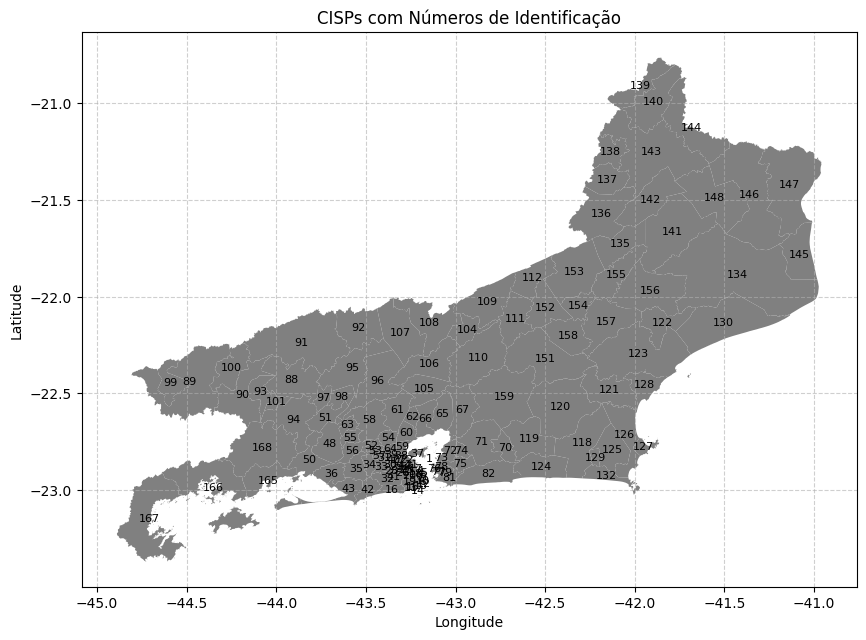

In [17]:
plt.figure(figsize=(10, 10))
ax = plt.gca()
cisp_df.plot(ax=ax, color='gray', linewidth=0.5)

for idx, row in cisp_df.iterrows():
    if row['geometry'] is not None and not row['geometry'].is_empty:
        centroid = row['geometry'].centroid
        ax.text(centroid.x, centroid.y, str(row['cisp']),
                fontsize=8, ha='center', va='center', color='black')

plt.title('CISPs com Números de Identificação')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Queremos realizar a análise apenas de linhas do município do Rio de Janeiro, portanto, trabalharemos apenas com as 41 primeiras CISPs, de números 1 a 44.

In [18]:
cisp_df_municipio = cisp_df[(cisp_df['cisp'] >= 1) & (cisp_df['cisp'] <= 44)]
cisp_df_municipio.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 41 entries, 19 to 136
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   cisp        41 non-null     int64   
 1   aisp        41 non-null     int64   
 2   shape_Leng  41 non-null     float64 
 3   shape_Area  41 non-null     float64 
 4   AREA_GEO    41 non-null     float64 
 5   geometry    41 non-null     geometry
dtypes: float64(3), geometry(1), int64(2)
memory usage: 2.2 KB


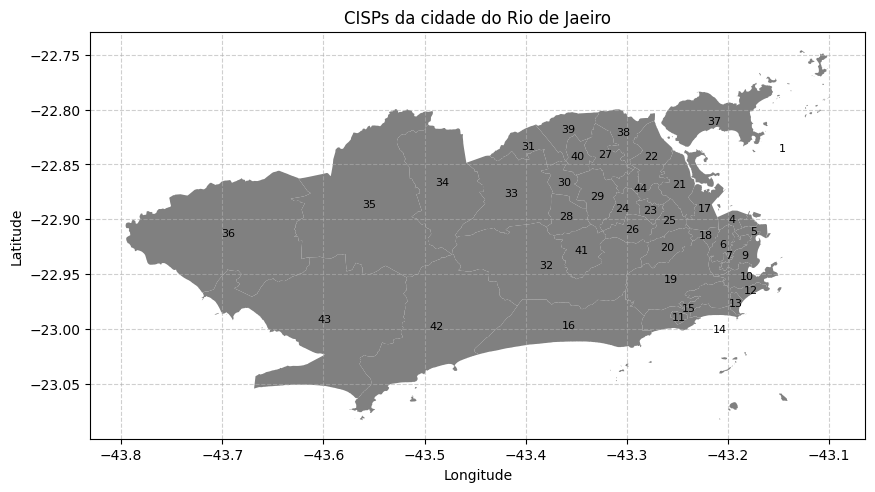

In [19]:
plt.figure(figsize=(10, 10))
ax = plt.gca()
cisp_df_municipio.plot(ax=ax, color='gray', linewidth=0.5)

for idx, row in cisp_df_municipio.iterrows():
    if row['geometry'] is not None and not row['geometry'].is_empty:
        centroid = row['geometry'].centroid
        ax.text(centroid.x, centroid.y, str(row['cisp']),
                fontsize=8, ha='center', va='center', color='black')

plt.title('CISPs da cidade do Rio de Jaeiro')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Importando dados de limites de bairro da prefeitura

Os dados da plataforma Fogo Cruzado são organizados por bairros. Para conseguir associar as linhas de ônibus aos bairros, precisamos importar os dados de limites de bairros disponibilizados pela prefeitura [aqui](https://www.data.rio/datasets/PCRJ::limite-de-bairros/about).

In [20]:
bairros_df = gpd.read_file('/content/PS-2026.1/data/dataRio/limiteBairros.geojson')
bairros_df.head()

,objectid,nome,regiao_adm,area_plane,codbairro,codra,codbnum,link,rp,cod_rp,codbairro_long,st_areashape,st_perimetershape,geometry
0,325,Paquetá,PAQUETA,1,013,21,13,Paqueta&area=013 ...,Centro,1.1,13,1705689.1178,24841.4600,"MULTIPOLYGON (((-43.10571 -22.74889, -43.10572..."
1,326,Freguesia (Ilha),ILHA DO GOVERNADOR,3,098,20,98,Freguesia (Ilha) &area=98 ...,Ilha do Governador,3.7,98,4056413.7580,18303.6214,"MULTIPOLYGON (((-43.17174 -22.77662, -43.17174..."
2,327,Bancários,ILHA DO GOVERNADOR,3,097,20,97,Bancários &area=97 ...,Ilha do Governador,3.7,97,978049.1823,7758.7919,"MULTIPOLYGON (((-43.18919 -22.78319, -43.18919..."
3,328,Galeão,ILHA DO GOVERNADOR,3,104,20,104,Galeão &area=104 ...,Ilha do Governador,3.7,104,18957473.3781,21510.0884,"MULTIPOLYGON (((-43.22808 -22.78375, -43.22816..."
4,329,Tauá,ILHA DO GOVERNADOR,3,101,20,101,Tauá &area=101 ...,Ilha do Governador,3.7,101,1672550.2781,8246.1207,"POLYGON ((-43.18044 -22.79941, -43.18026 -22.7..."


Para deixar os nomes dos bairros consistentes com a grafia usada nos dados do Fogo Cruzado que serão importados a seguir, vamos remover acentos e deixar os nomes em maiúsculas

In [21]:
bairros_df['nome'] = (
    bairros_df['nome']
    .astype(str)
    .apply(lambda x: unicodedata.normalize('NFKD', x)
           .encode('ASCII', 'ignore')
           .decode('utf-8'))
    .str.upper()
)

bairros_df.head()

,objectid,nome,regiao_adm,area_plane,codbairro,codra,codbnum,link,rp,cod_rp,codbairro_long,st_areashape,st_perimetershape,geometry
0,325,PAQUETA,PAQUETA,1,013,21,13,Paqueta&area=013 ...,Centro,1.1,13,1705689.1178,24841.4600,"MULTIPOLYGON (((-43.10571 -22.74889, -43.10572..."
1,326,FREGUESIA (ILHA),ILHA DO GOVERNADOR,3,098,20,98,Freguesia (Ilha) &area=98 ...,Ilha do Governador,3.7,98,4056413.7580,18303.6214,"MULTIPOLYGON (((-43.17174 -22.77662, -43.17174..."
2,327,BANCARIOS,ILHA DO GOVERNADOR,3,097,20,97,Bancários &area=97 ...,Ilha do Governador,3.7,97,978049.1823,7758.7919,"MULTIPOLYGON (((-43.18919 -22.78319, -43.18919..."
3,328,GALEAO,ILHA DO GOVERNADOR,3,104,20,104,Galeão &area=104 ...,Ilha do Governador,3.7,104,18957473.3781,21510.0884,"MULTIPOLYGON (((-43.22808 -22.78375, -43.22816..."
4,329,TAUA,ILHA DO GOVERNADOR,3,101,20,101,Tauá &area=101 ...,Ilha do Governador,3.7,101,1672550.2781,8246.1207,"POLYGON ((-43.18044 -22.79941, -43.18026 -22.7..."


A seguir, uma visualização geográfica das formas geométricas importadas para garante a corretude dos dados.

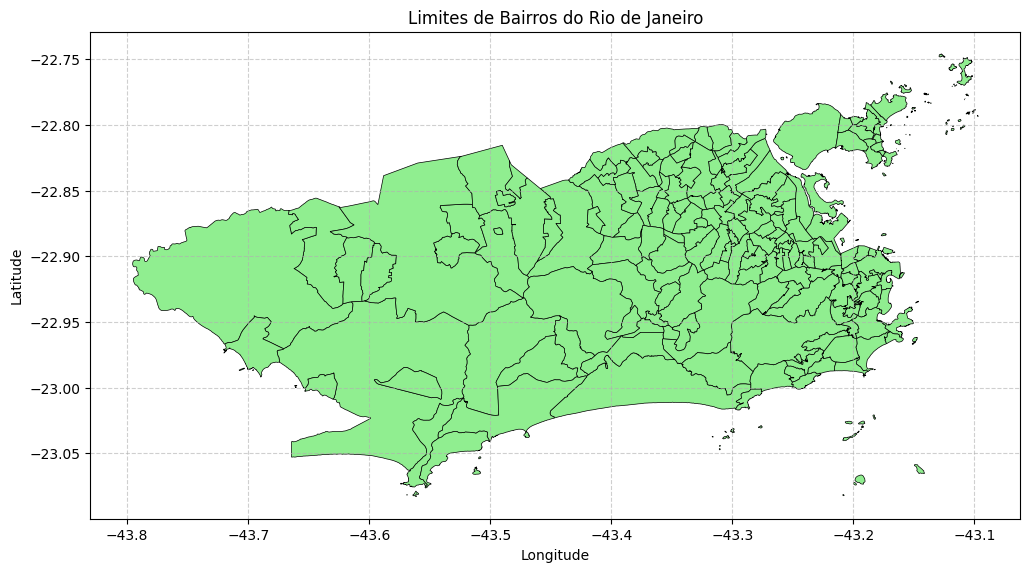

In [22]:
plt.figure(figsize=(12, 10))
bairros_df.plot(ax=plt.gca(), color='lightgreen', edgecolor='black', linewidth=0.5)
plt.title('Limites de Bairros do Rio de Janeiro')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Importando dados da Série Histórica do ISP

Vamos importar dados referentes às categorias Roubo em coletivo e Furto e coletivo do [site do Instituto de Segurança Pùblica](https://ispconecta.rj.gov.br/serie_historica/).

#### Roubos em coletivo

Como são 41 CISPs, importamos os dados de todas (disponíveis em 41 arquivos .csv distintos) e agregamos especificando a CISP em uma coluna presente em cada observação.

In [23]:
# Import dos .csv de roubo em coletivo

# Caminho dos arquivos
path = "/content/PS-2026.1/data/isp/serieHistorica/roubo/*.csv"

# Lista todos os csv
files = glob.glob(path)

dfs = []

for file in files:

    # Lê o csv, tentando com delimitador ';'
    try:
        df = pd.read_csv(file, sep=';')
    except Exception as e:
        print(f"Erro ao ler o arquivo {file} com separador ';': {e}")
        # Se falhar com ';', tenta com o delimitador padrão ','
        try:
            df = pd.read_csv(file)
        except Exception as e_default:
            print(f"Erro ao ler o arquivo {file} com separador padrão ',': {e_default}")
            continue # Pula para o próximo arquivo se ambos falharem

    # Nome do arquivo
    filename = os.path.basename(file)

    # Extrai o número da CISP
    # Ex: roubo_coletivo_cisp_1.csv -> 1
    match = re.search(r'cisp_(\d+)', filename)

    if match:
        cisp = int(match.group(1))
    else:
        cisp = None

    # Adiciona coluna
    df['cisp'] = cisp

    dfs.append(df)

# Junta tudo
roubo_coletivo_isp_df = pd.concat(dfs, ignore_index=True)

# Cada .csv tem 11 linhas e como tem 41 CISPs, ficam no total 451 linhas

print("Todos os arquivos CSV foram processados e concatenados.")
print(f"DataFrame final tem {len(roubo_coletivo_isp_df)} linhas e {len(roubo_coletivo_isp_df.columns)} colunas.")

Todos os arquivos CSV foram processados e concatenados.
DataFrame final tem 451 linhas e 17 colunas.


In [24]:
roubo_coletivo_isp_df.head(11)

,Unnamed: 0,jan,fev,mar,abr,mai,jun,jul,ago,set,out,nov,dez,total,Dif,Dif_perc,cisp
0,2016,NaN,NaN,NaN,12.0000,10.0000,19.0000,21.0000,27.0000,22.0000,22.0000,29.0000,31.0000,193,NaN,NaN,34
1,2017,9.0000,4.0000,15.0000,23.0000,27.0000,45.0000,38.0000,33.0000,30.0000,17.0000,20.0000,31.0000,292,99.0000,"51,3",34
2,2018,27.0000,29.0000,25.0000,25.0000,34.0000,30.0000,54.0000,24.0000,31.0000,27.0000,35.0000,33.0000,374,82.0000,"28,08",34
3,2019,36.0000,14.0000,10.0000,48.0000,39.0000,24.0000,27.0000,51.0000,38.0000,25.0000,33.0000,44.0000,389,15.0000,"4,01",34
4,2020,32.0000,32.0000,25.0000,25.0000,20.0000,22.0000,15.0000,15.0000,5.0000,16.0000,13.0000,18.0000,238,-151.0000,"-38,82",34
5,2021,31.0000,43.0000,43.0000,27.0000,37.0000,38.0000,28.0000,18.0000,25.0000,23.0000,19.0000,14.0000,346,108.0000,"45,38",34
6,2022,16.0000,10.0000,10.0000,8.0000,8.0000,14.0000,13.0000,4.0000,9.0000,8.0000,15.0000,12.0000,127,-219.0000,"-63,29",34
7,2023,4.0000,8.0000,6.0000,9.0000,6.0000,9.0000,27.0000,31.0000,22.0000,13.0000,18.0000,9.0000,162,35.0000,"27,56",34
8,2024,9.0000,9.0000,7.0000,9.0000,11.0000,15.0000,7.0000,12.0000,23.0000,16.0000,4.0000,15.0000,137,-25.0000,"-15,43",34
9,2025,22.0000,9.0000,4.0000,11.0000,6.0000,2.0000,1.0000,4.0000,9.0000,5.0000,2.0000,0.0000,75,-62.0000,"-45,26",34


Verificamos que os valores nulos ocorrem apenas na forma esperada, ou seja, 1 vez por CISP para cada mês, que são periódos em que não extraímos os dados (jan-mar de 2016 e abr-dez de 2026).

In [25]:
roubo_coletivo_isp_df.isna().sum()

,0
Unnamed: 0,0
jan,41
fev,41
mar,41
abr,41
mai,41
jun,41
jul,41
ago,41
set,41


Vamos visualizar os dados ao longo do tempo para uma CISP específica e depois o agregado de todas as CISPs. Definiremos também uma função transformar_isp_para_longo que será útil na construção de séries temporais posteriormente.

Observando o segundo gráfico, é possível notar uma tendência geral de diminuição dos roubos ao longo dos últimos anos.

In [26]:
def transformar_isp_para_longo(
    isp_df,
    nome_indicador="roubo_coletivo",
    col_ano="Unnamed: 0",
    col_cisp="cisp"
):
    meses_map = {
        "jan": 1,
        "fev": 2,
        "mar": 3,
        "abr": 4,
        "mai": 5,
        "jun": 6,
        "jul": 7,
        "ago": 8,
        "set": 9,
        "out": 10,
        "nov": 11,
        "dez": 12,
    }

    meses_cols = list(meses_map.keys())

    df = isp_df.copy()

    df = df.rename(columns={col_ano: "ano"})
    df["ano"] = df["ano"].astype(int)
    df[col_cisp] = df[col_cisp].astype(int)

    df_longo = df.melt(
        id_vars=["ano", col_cisp],
        value_vars=meses_cols,
        var_name="mes_nome",
        value_name=nome_indicador
    )

    df_longo["mes"] = df_longo["mes_nome"].map(meses_map)

    df_longo["data_mes"] = pd.to_datetime(
        dict(
            year=df_longo["ano"],
            month=df_longo["mes"],
            day=1
        )
    )

    df_longo[nome_indicador] = pd.to_numeric(
        df_longo[nome_indicador],
        errors="coerce"
    )

    df_longo = df_longo.dropna(subset=[nome_indicador])

    return df_longo[["data_mes", "ano", "mes", col_cisp, nome_indicador]]

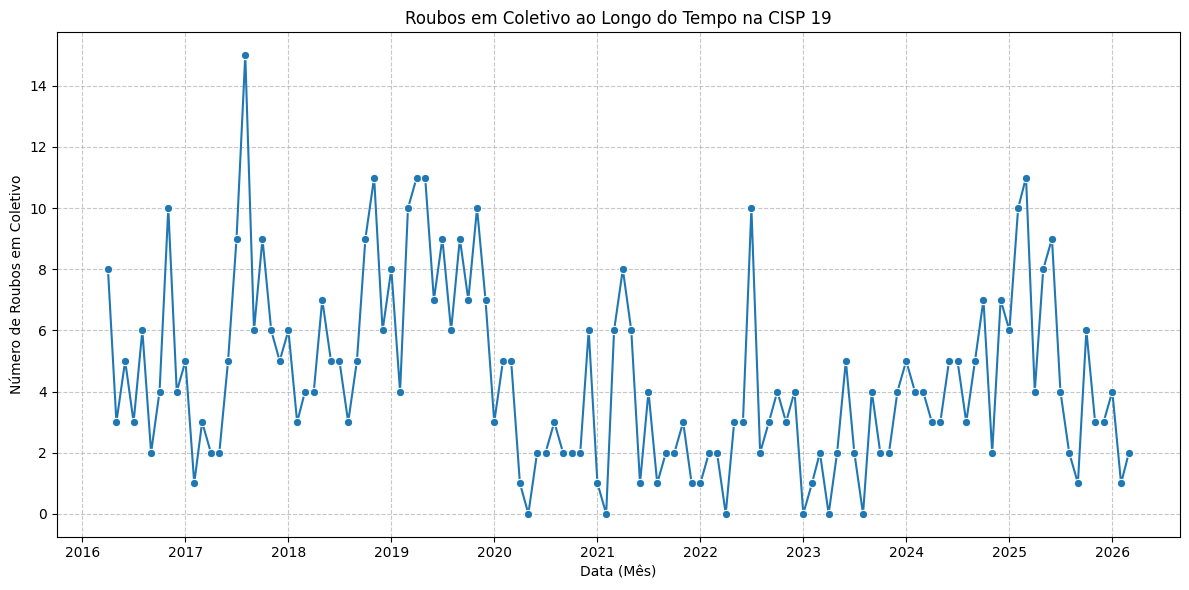

In [27]:
isp_roubo_longo = transformar_isp_para_longo(
    roubo_coletivo_isp_df,
    nome_indicador="roubo_coletivo"
)

# Filtrar para a CISP 1
cisp_1_df = isp_roubo_longo[isp_roubo_longo['cisp'] == 19]

plt.figure(figsize=(12, 6))
sns.lineplot(data=cisp_1_df, x='data_mes', y='roubo_coletivo', marker='o')
plt.title('Roubos em Coletivo ao Longo do Tempo na CISP 19')
plt.xlabel('Data (Mês)')
plt.ylabel('Número de Roubos em Coletivo')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

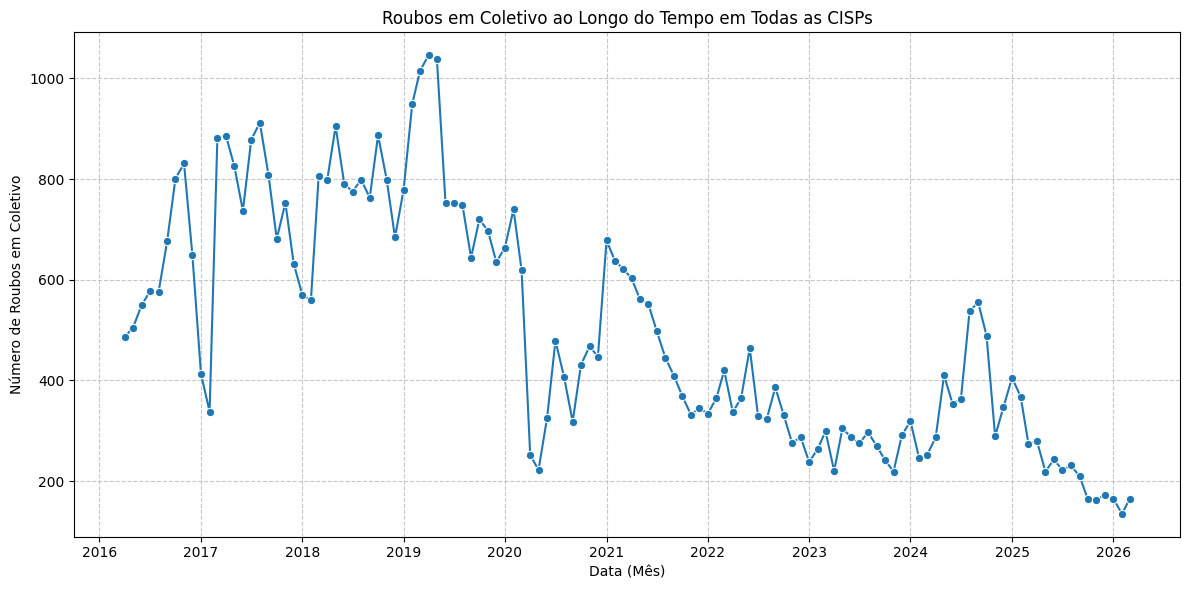

In [28]:
total_roubo_cisps = isp_roubo_longo.groupby('data_mes')['roubo_coletivo'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=total_roubo_cisps, x='data_mes', y='roubo_coletivo', marker='o')
plt.title('Roubos em Coletivo ao Longo do Tempo em Todas as CISPs')
plt.xlabel('Data (Mês)')
plt.ylabel('Número de Roubos em Coletivo')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Furtos em coletivo

Fizemos os mesmo processo para os Furtos em coletivo. Para os dados de furto, não foi possível observar uma tendência de queda ou aumento agregados.

In [29]:
# Import dos .csv de furto em coletivo

# Caminho dos arquivos
path = "/content/PS-2026.1/data/isp/serieHistorica/furto/*.csv"

# Lista todos os csv
files = glob.glob(path)

dfs = []

for file in files:

    # Lê o csv, tentando com delimitador ';'
    try:
        df = pd.read_csv(file, sep=';')
    except Exception as e:
        print(f"Erro ao ler o arquivo {file} com separador ';': {e}")
        # Se falhar com ';', tenta com o delimitador padrão ','
        try:
            df = pd.read_csv(file)
        except Exception as e_default:
            print(f"Erro ao ler o arquivo {file} com separador padrão ',': {e_default}")
            continue # Pula para o próximo arquivo se ambos falharem

    # Nome do arquivo
    filename = os.path.basename(file)

    # Extrai o número da CISP
    # Ex: 1.csv -> 1
    match = re.search(r'(\d+)', filename)

    if match:
        cisp = int(match.group(1))
    else:
        cisp = None

    # Adiciona coluna
    df['cisp'] = cisp

    dfs.append(df)

# Junta tudo
furto_coletivo_isp_df = pd.concat(dfs, ignore_index=True)

# Cada .csv tem 11 linhas e como tem 41 CISPs, ficam no total 451 linhas

print("Todos os arquivos CSV foram processados e concatenados.")
print(f"DataFrame final tem {len(furto_coletivo_isp_df)} linhas e {len(furto_coletivo_isp_df.columns)} colunas.")

Todos os arquivos CSV foram processados e concatenados.
DataFrame final tem 451 linhas e 17 colunas.


In [30]:
furto_coletivo_isp_df.head(11)

,Unnamed: 0,jan,fev,mar,abr,mai,jun,jul,ago,set,out,nov,dez,total,Dif,Dif_perc,cisp
0,2016,NaN,NaN,NaN,2.0000,2.0000,4.0000,2.0000,6.0000,1.0000,2.0000,3.0000,1.0000,23,NaN,NaN,26
1,2017,3.0000,1.0000,9.0000,4.0000,6.0000,6.0000,10.0000,6.0000,7.0000,4.0000,7.0000,14.0000,77,54.0000,"234,78",26
2,2018,6.0000,6.0000,10.0000,10.0000,8.0000,12.0000,9.0000,8.0000,9.0000,8.0000,8.0000,1.0000,95,18.0000,"23,38",26
3,2019,5.0000,4.0000,4.0000,7.0000,10.0000,8.0000,13.0000,6.0000,7.0000,7.0000,6.0000,4.0000,81,-14.0000,"-14,74",26
4,2020,4.0000,8.0000,6.0000,0.0000,0.0000,0.0000,0.0000,3.0000,1.0000,2.0000,2.0000,1.0000,27,-54.0000,"-66,67",26
5,2021,0.0000,2.0000,8.0000,3.0000,7.0000,6.0000,5.0000,8.0000,4.0000,3.0000,14.0000,8.0000,68,41.0000,"151,85",26
6,2022,7.0000,10.0000,11.0000,10.0000,16.0000,22.0000,17.0000,11.0000,9.0000,7.0000,14.0000,8.0000,142,74.0000,"108,82",26
7,2023,12.0000,3.0000,3.0000,7.0000,5.0000,11.0000,4.0000,16.0000,12.0000,15.0000,17.0000,10.0000,115,-27.0000,"-19,01",26
8,2024,17.0000,10.0000,14.0000,21.0000,19.0000,26.0000,13.0000,14.0000,9.0000,18.0000,22.0000,21.0000,204,89.0000,"77,39",26
9,2025,14.0000,17.0000,15.0000,12.0000,9.0000,11.0000,21.0000,18.0000,9.0000,13.0000,16.0000,16.0000,171,-33.0000,"-16,18",26


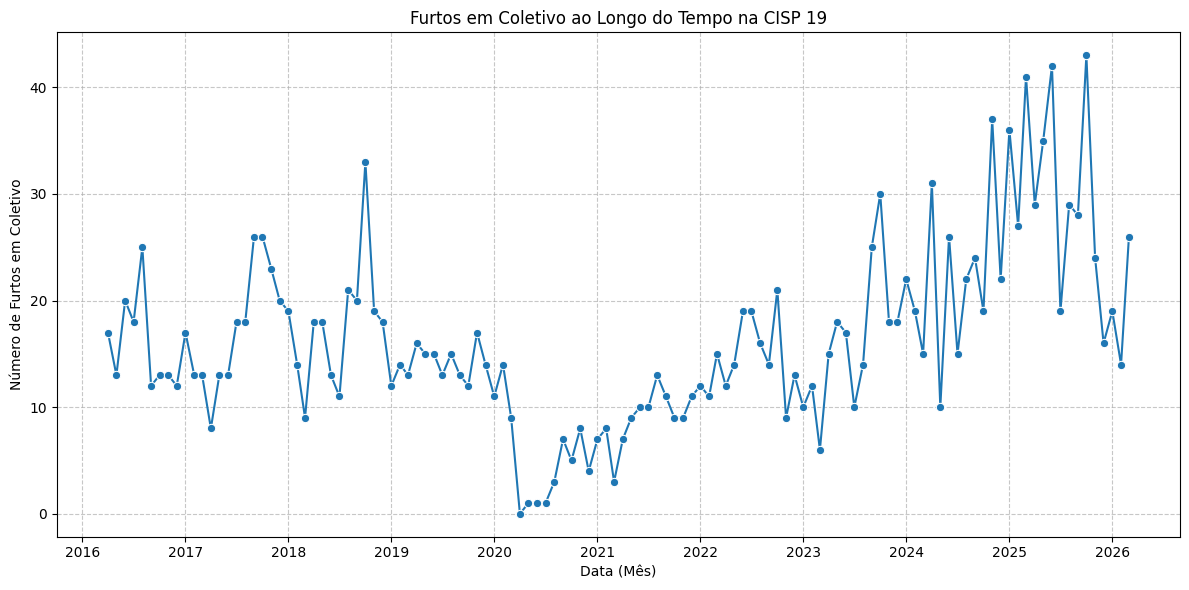

In [31]:
isp_furto_longo = transformar_isp_para_longo(
    furto_coletivo_isp_df,
    nome_indicador="furto_coletivo"
)

# Filtrar para a CISP 1
cisp_1_df = isp_furto_longo[isp_furto_longo['cisp'] == 19]

plt.figure(figsize=(12, 6))
sns.lineplot(data=cisp_1_df, x='data_mes', y='furto_coletivo', marker='o')
plt.title('Furtos em Coletivo ao Longo do Tempo na CISP 19')
plt.xlabel('Data (Mês)')
plt.ylabel('Número de Furtos em Coletivo')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

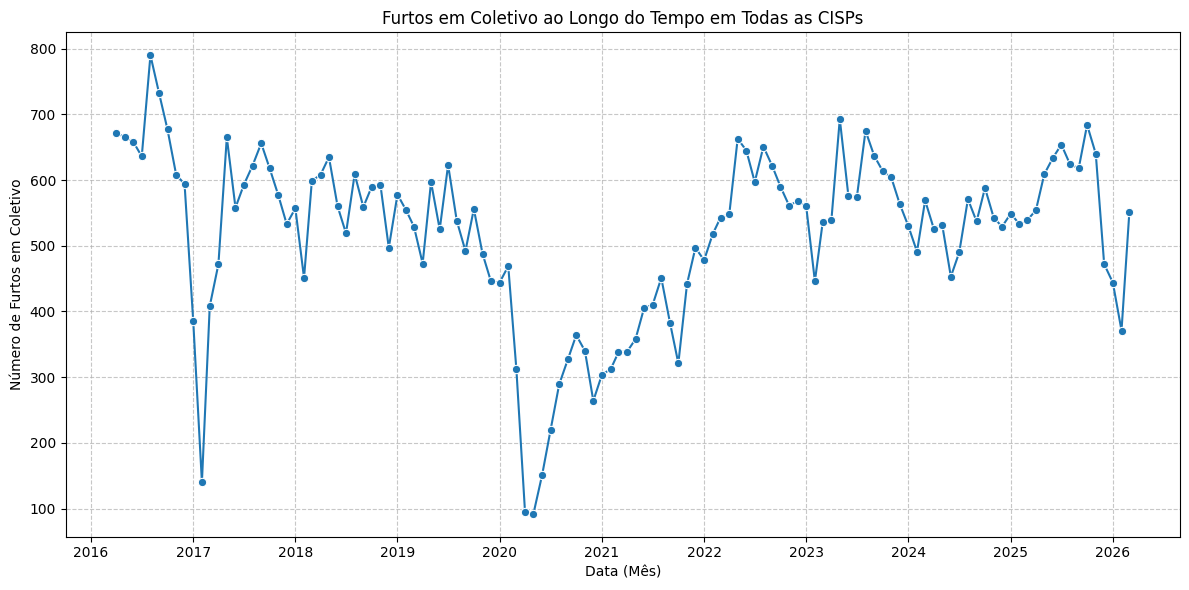

In [32]:
total_furto_cisps = isp_furto_longo.groupby('data_mes')['furto_coletivo'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=total_furto_cisps, x='data_mes', y='furto_coletivo', marker='o')
plt.title('Furtos em Coletivo ao Longo do Tempo em Todas as CISPs')
plt.xlabel('Data (Mês)')
plt.ylabel('Número de Furtos em Coletivo')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Importando dados de violência armada da plataforma Fogo Cruzado

A partir [desta página](https://api.fogocruzado.org.br/search), é possível obter as estatísticas detalhadas de violência armada nos limites geográficos do município do Rio de Janeiro.

Importamos os dados referentes ao período de julho de 2016 até março de 2026. Nosso objetivo era obter uma série temporal dos útimos 10 anos de dados, ou seja, de abril de 2016 até março de 2026. Não obstante, estão disponíveis os dados a partir de julho, o que acreditamos que não terá um impacto significativo na análise.

In [33]:
# Caminho para a pasta com os dados do Fogo Cruzado
fogo_cruzado_path = '/content/PS-2026.1/data/fogoCruzado/'

# Lista para armazenar os dataframes de cada arquivo
df_list = []

# Encontrar todos os arquivos CSV na pasta
csv_files = glob.glob(fogo_cruzado_path + '*.csv')

# Iterar sobre os arquivos CSV, ler e adicionar à lista
for file in csv_files:
    try:
        df = pd.read_csv(file, encoding='utf-8')
        df_list.append(df)
    except UnicodeDecodeError:
        # Tentar outra codificação se a primeira falhar
        df = pd.read_csv(file, encoding='latin1')
        df_list.append(df)
    except Exception as e:
        print(f"Erro ao ler o arquivo {file}: {e}")


# PARA NÃO CONCATENAR COMMENTAR O CODIGO ABAIXO E ACESSAR CADA df INDIVIDUAL EM
# df_list[]
# Concatenar todos os dataframes em um único dataframe
fogo_cruzado_df = pd.concat(df_list, ignore_index=True)

In [34]:
fogo_cruzado_df.head()

,id,address,region,state,city,neighborhood,sub_neighborhood,locality,latitude,longitude,...,men_dead,men_wounded,women_dead,women_wounded,kids_dead,kids_wounded,teenagers_dead,teenagers_wounded,elderly_dead,elderly_wounded
0,42437,"Favela da Palmeirinha, Honório Gurgel, Rio de ...",Sudeste,Rio de Janeiro,Rio de Janeiro,HONORIO GURGEL,NaN,FAVELA DA PALMEIRINHA,-22.8484,-43.3661,...,0,0,0,0,0,0,0,0,0,0
1,42415,"R. Javata - Anchieta, Rio de Janeiro - RJ, Brasil",Sudeste,Rio de Janeiro,Rio de Janeiro,ANCHIETA,NaN,JAVATA (COMPLEXO DO CHAPADAO),-22.8231,-43.3861,...,0,0,0,0,0,0,0,0,0,0
2,42417,"Morro da Formiga - Tijuca, Rio de Janeiro - RJ...",Sudeste,Rio de Janeiro,Rio de Janeiro,TIJUCA,NaN,MORRO DA FORMIGA,-22.9442,-43.2408,...,0,0,0,0,0,0,0,0,0,0
3,42428,"Fazendinha - Complexo do Alemão, Rio de Janeir...",Sudeste,Rio de Janeiro,Rio de Janeiro,COMPLEXO DO ALEMAO,NaN,FAZENDINHA (COMPLEXO DO ALEMAO),-22.8594,-43.2754,...,0,0,0,0,0,0,0,0,0,0
4,42425,"R. Sen. Nabuco - Vila Isabel, Rio de Janeiro -...",Sudeste,Rio de Janeiro,Rio de Janeiro,VILA ISABEL,NaN,MORRO DOS MACACOS,-22.9135,-43.2503,...,0,0,0,0,0,0,0,0,0,0


Verificamos que existem 28166 registros de ocorrências no referido período e examinamos os nomes das colunas disponíveis.

In [35]:
fogo_cruzado_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28166 entries, 0 to 28165
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    28166 non-null  int64  
 1   address               28166 non-null  object 
 2   region                28166 non-null  object 
 3   state                 28166 non-null  object 
 4   city                  28166 non-null  object 
 5   neighborhood          28166 non-null  object 
 6   sub_neighborhood      159 non-null    object 
 7   locality              19873 non-null  object 
 8   latitude              28166 non-null  float64
 9   longitude             28166 non-null  float64
 10  data                  28166 non-null  object 
 11  police_action         28166 non-null  bool   
 12  agent_presence        28166 non-null  bool   
 13  police_unit           7890 non-null   object 
 14  main_reason           28166 non-null  object 
 15  complementary_reaso

Abaixo, verificamos que existe apenas uma cidade nos dados (que, pelo head, sabemos de Rio de Janeiro), conforme esperado.

In [36]:
fogo_cruzado_df.nunique()

,0
id,28166
address,13498
region,1
state,1
city,1
neighborhood,162
sub_neighborhood,36
locality,639
latitude,12567
longitude,12574


Também analisamos os dados nulos em cada coluna, e verificamos que eles estão presentes apenas em colunas que acreditamos que não irão interferir em nossa análise.

In [37]:
fogo_cruzado_df.isnull().sum()

,0
id,0
address,0
region,0
state,0
city,0
neighborhood,0
sub_neighborhood,28007
locality,8293
latitude,0
longitude,0


Verificamos se havia alguma menção específica a ônibus ou coletivo na coluna de razão do tiroteio. No entanto, essa informação não foi encontrada. Isso não é um problema, pois o objetivo desse dataset é de fornecer uma estimativa da segurança dos bairros atravessados por meio do número de tiroteios.

In [38]:
print("Razões principais únicas:\n", fogo_cruzado_df['main_reason'].unique())
print("\nValores únicos na coluna 'complementary_reason':\n", fogo_cruzado_df['complementary_reason'].unique())

Razões principais únicas:
 ['Disputa' 'Ação policial' 'Não identificado' 'Tentativa/Roubo'
 'Tentativa/Roubo de cargas' 'Operação policial' 'Homicidio/Tentativa'
 'Tiros a esmo' 'Briga' 'Ataque a civis' 'Arrastão'
 'Sequestro/Cárcere Privado' 'Tortura' 'Tentativa/Roubo a banco' 'Outro'
 'Disparo Acidental' 'Suicídio']

Valores únicos na coluna 'complementary_reason':
 [nan]


In [39]:
bus_related_keywords = ['ônibus', 'coletivo', 'coletivos']

# Verificar main_reason
main_reason_bus = fogo_cruzado_df['main_reason'].apply(lambda x: any(keyword in str(x).lower() for keyword in bus_related_keywords))
if main_reason_bus.any():
    print(f"\nEncontradas ocorrências relacionadas a ônibus na coluna 'main_reason':\n{fogo_cruzado_df[main_reason_bus]['main_reason'].unique()}")
else:
    print("\nNenhuma ocorrência direta relacionada a ônibus encontrada na coluna 'main_reason'.")

# Verificar complementary_reason (apesar de sabermos que está vazia)
complementary_reason_bus = fogo_cruzado_df['complementary_reason'].apply(lambda x: any(keyword in str(x).lower() for keyword in bus_related_keywords))
if complementary_reason_bus.any():
    print(f"\nEncontradas ocorrências relacionadas a ônibus na coluna 'complementary_reason':\n{fogo_cruzado_df[complementary_reason_bus]['complementary_reason'].unique()}")
else:
    print("\nNenhuma ocorrência direta relacionada a ônibus encontrada na coluna 'complementary_reason'.")


Nenhuma ocorrência direta relacionada a ônibus encontrada na coluna 'main_reason'.

Nenhuma ocorrência direta relacionada a ônibus encontrada na coluna 'complementary_reason'.


#### Consistência entre nomes de bairros entre datasets

Precisamos confirmar se os nomes dos bairros no dataFrame fogo_cruzado_df são os mesmos dos dados da Prefeitura, presentes em bairros_df.

In [40]:
# Padronizar a coluna 'neighborhood' do fogo_cruzado_df
fogo_cruzado_df['neighborhood_cleaned'] = (
    fogo_cruzado_df['neighborhood']
    .astype(str)
    .apply(lambda x: unicodedata.normalize('NFKD', x).encode('ASCII', 'ignore').decode('utf-8'))
    .str.upper()
)

# Obter os nomes únicos de bairros de cada DataFrame
bairros_df_nomes = set(bairros_df['nome'].unique())
fogo_cruzado_df_nomes = set(fogo_cruzado_df['neighborhood_cleaned'].unique())

print(f"Número de bairros únicos em bairros_df: {len(bairros_df_nomes)}")
print(f"Número de bairros únicos em fogo_cruzado_df: {len(fogo_cruzado_df_nomes)}")

# Encontrar bairros em comum
bairros_em_comum = bairros_df_nomes.intersection(fogo_cruzado_df_nomes)
print(f"\nBairros em comum entre os dois dataframes: {len(bairros_em_comum)}")

# Encontrar bairros apenas em bairros_df
bairros_apenas_bairros_df = bairros_df_nomes.difference(fogo_cruzado_df_nomes)
print(f"Bairros apenas em bairros_df: {len(bairros_apenas_bairros_df)}")
print(bairros_apenas_bairros_df) # Descomente para ver a lista de bairros

# Encontrar bairros apenas em fogo_cruzado_df
bairros_apenas_fogo_cruzado_df = fogo_cruzado_df_nomes.difference(bairros_df_nomes)
print(f"Bairros apenas em fogo_cruzado_df: {len(bairros_apenas_fogo_cruzado_df)}")
print(bairros_apenas_fogo_cruzado_df) # Descomente para ver a lista de bairros


Número de bairros únicos em bairros_df: 166
Número de bairros únicos em fogo_cruzado_df: 162

Bairros em comum entre os dois dataframes: 160
Bairros apenas em bairros_df: 6
{'ARGENTINO', 'ILHA DE GUARATIBA', 'JABOUR', 'IMPERIAL DE SAO CRISTOVAO', 'ZUMBI', 'PAQUETA'}
Bairros apenas em fogo_cruzado_df: 2
{'SAO CRISTOVAO', 'NI'}


Descobrimos algumas discrepâncias entre os dados.

Os bairro Argentino foi recentemente criado, por isso, ainda não consta nos registros do Fogo Cruzado.

Zumbi, Paquetá, são bairros bem pequenos que muito provavelmente não possuem ocorrências.

Jabour e Ilha de Guaratiba provavelmente por possuirem áreas pequeas e serem vistos como sub-bairros podem ter suas ocorrências registradas em bairros ajacentes. Como acreditamos que esses números também não são expressivos, vamos apenas desconsiderar o fato de não aparecerem na base do Fogo Cruzado.

Quanto à NI (Não Informado), verificamos que existem apenas 9 registros, que, portanto, serão removidos do fogo_cruzado_df.

Já São Cristóvão precisou ser renomeado em bairros_df de IMPERAL DE SAO CRISTOVAO para SAO CRISTOVAO visando a adequação.

In [41]:
len(fogo_cruzado_df.loc[fogo_cruzado_df["neighborhood"] == 'NI'])

9

In [42]:
# Remover registros onde 'neighborhood_cleaned' é 'NI'
initial_count = len(fogo_cruzado_df)
fogo_cruzado_df = fogo_cruzado_df[fogo_cruzado_df['neighborhood_cleaned'] != 'NI']
removed_count = initial_count - len(fogo_cruzado_df)
print(f"Removidos {removed_count} registros com 'NI' na coluna 'neighborhood_cleaned'.")
print(f"Novo número de registros em fogo_cruzado_df: {len(fogo_cruzado_df)}")


Removidos 9 registros com 'NI' na coluna 'neighborhood_cleaned'.
Novo número de registros em fogo_cruzado_df: 28157


In [43]:
# Alterar 'IMPERIAL DE SAO CRISTOVAO' para 'SAO CRISTOVAO' em bairros_df
bairros_df.loc[bairros_df['nome'] == 'IMPERIAL DE SAO CRISTOVAO', 'nome'] = 'SAO CRISTOVAO'

print("Nomes de bairro atualizados em bairros_df.")
# Verificação da alteração
print(bairros_df[bairros_df['nome'] == 'SAO CRISTOVAO'][['nome']])


Nomes de bairro atualizados em bairros_df.
             nome
79  SAO CRISTOVAO


#### Ranking de bairros

Para ter uma dimensão dos bairros e do formatos dos dados decidimos ranquear os bairros pelo número de ocorrências.

In [44]:
ranking_bairros_perigosos = (
    fogo_cruzado_df['neighborhood']
    .value_counts()
    .reset_index()
)
ranking_bairros_perigosos.columns = ['Bairro', 'Total de Ocorrências']

ranking_bairros_perigosos.head()

,Bairro,Total de Ocorrências
0,VILA KENNEDY,1556
1,COMPLEXO DO ALEMAO,1108
2,PRACA SECA,1087
3,CIDADE DE DEUS,1071
4,TIJUCA,876


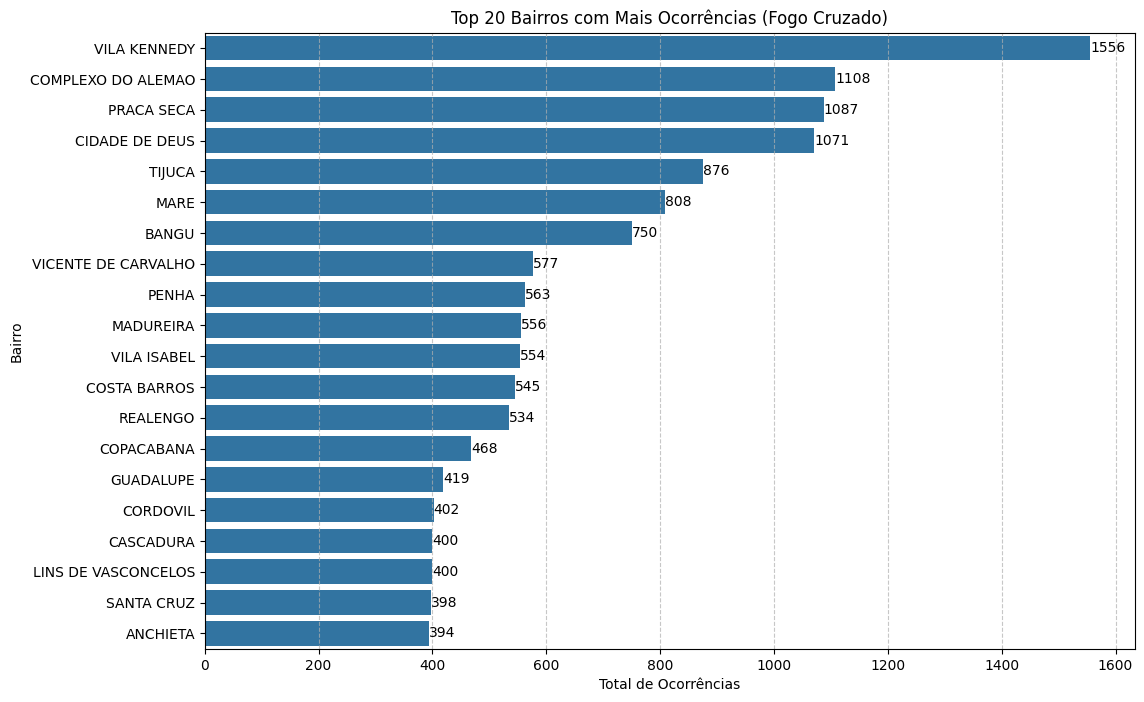

In [45]:
plt.figure(figsize=(12, 8))
top_20_bairros = ranking_bairros_perigosos.head(20)

ax = sns.barplot(data=top_20_bairros, y='Bairro', x='Total de Ocorrências',  legend=False)
for container in ax.containers:
    ax.bar_label(container)

plt.title('Top 20 Bairros com Mais Ocorrências (Fogo Cruzado)')
plt.xlabel('Total de Ocorrências')
plt.ylabel('Bairro')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Para ter uma noção da distribuição geográfica dos dados, vamos também visualizar um mapa com as ocorrências por bairro

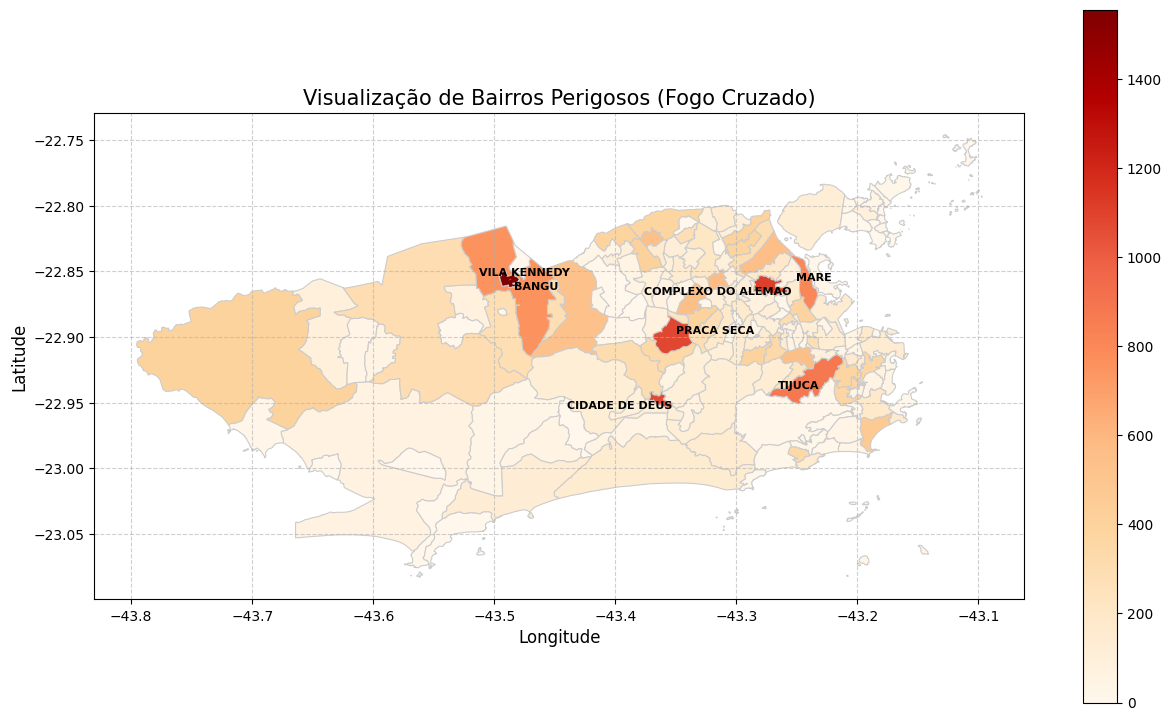

In [46]:

# 1. Mesclar os dados de ranking de bairros com o GeoDataFrame de bairros
# Primeiro, garantimos que os nomes dos bairros estão em um formato consistente para o merge

bairros_perigosos_merged = bairros_df.merge(
    ranking_bairros_perigosos[['Bairro', 'Total de Ocorrências']],
    left_on='nome',
    right_on='Bairro',
    how='left'
)

# Preencher NaN em 'Total de Ocorrências' com 0 para bairros sem ocorrências no ranking
bairros_perigosos_merged['Total de Ocorrências'] = bairros_perigosos_merged['Total de Ocorrências'].fillna(0)

# 2. Criar a visualização geográfica
fig, ax = plt.subplots(1, 1, figsize=(15, 9))

# Plotar o mapa coroplético
bairros_perigosos_merged.plot(
    column='Total de Ocorrências',
    cmap='OrRd', # Colormap para representar a quantidade de ocorrências
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    )

# Adicionar os nomes dos bairros com mais de 600 ocorrências
texts = [] # Lista para armazenar os objetos de texto
for idx, row in bairros_perigosos_merged.iterrows():
    if row['geometry'] is not None and not row['geometry'].is_empty and row['Total de Ocorrências'] > 600:
        try:
            centroid = row['geometry'].centroid
            # Adiciona o objeto de texto à lista, em vez de plotá-lo diretamente
            texts.append(ax.text(centroid.x, centroid.y, row['nome'],
                                  fontsize=8, ha='center', va='center', color='black', fontweight='semibold'))
        except Exception as e:
            print(f"Could not plot centroid for {row['nome']}: {e}")

# Ajustar a posição dos textos para evitar sobreposição
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

ax.set_title('Visualização de Bairros Perigosos (Fogo Cruzado)', fontsize=15)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

Nota-se uma concentracão de ocorrências em bairros específicos das zonas Norte e Oeste, especialmente no bairros de Vila Kennedy, Maré, Complexo do Alemão, Tijuca, Cidade de Deus, Praça Seca e Bangu. Portanto, espera-se que linhas que passem por esses bairros tenham um índice maior.

#### Análise Temporal

Vamos verificar também a temporalidade dos dados. Primeiro, faremos algumas conversões que facilitarão a manipulação de dados temporais.

In [47]:
# Conversão para datetime para auxiliar na análise temporal
fogo_cruzado_df["data"] = pd.to_datetime(
    fogo_cruzado_df["data"]
)

/tmp/ipykernel_99568/2489858227.py:2: UserWarning: Parsing dates in %d/%m/%Y, %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  fogo_cruzado_df["data"] = pd.to_datetime(


In [48]:
fogo_cruzado_df['data'].head()

,data
0,2021-03-31 21:00:00
1,2021-04-01 03:18:00
2,2021-04-01 04:08:00
3,2021-04-01 07:22:00
4,2021-04-01 08:45:00


In [49]:
# Extrair cada ano, mes, dia e hora para uma coluna no dataframe

fogo_cruzado_df["ano"] = fogo_cruzado_df["data"].dt.year
fogo_cruzado_df["mes"] = fogo_cruzado_df["data"].dt.month
fogo_cruzado_df["nome_mes"] = fogo_cruzado_df["data"].dt.month_name()
fogo_cruzado_df["dia_semana"] = fogo_cruzado_df["data"].dt.day_name()
fogo_cruzado_df["hora"] = fogo_cruzado_df["data"].dt.hour

##### Quantidade de ocorrências por ano

Fazendo a análise por ano, mesmo desconsiderando os anos de 2016 e 2026 (que estão incompletos) percebemos um claro pico de violência armada em 2018 e uma redução consistente após esse ano.

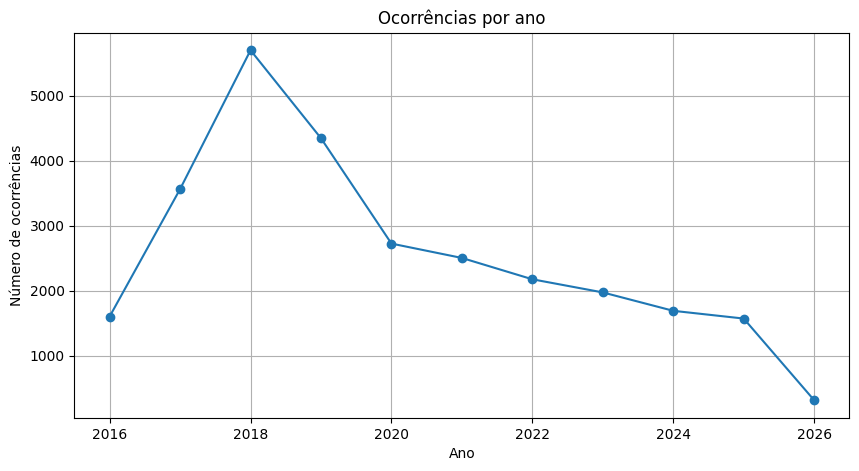

In [50]:
ocorrencias_ano = (
    fogo_cruzado_df
    .groupby("ano")
    .size()
)
ocorrencias_ano.plot(
    kind="line",
    marker='o',
    figsize=(10,5)
)

plt.title("Ocorrências por ano")
plt.xlabel("Ano")
plt.ylabel("Número de ocorrências")

plt.grid(True)
plt.show()

##### Quantidade de ocorrências por mes em todo período

Vamos calcular a média de ocorrências por mês agrupando por mês. Precisamos considerar que como tomamos um período de julho a março, teremos 10 ocorrências para alguns meses, e 9 para outros.

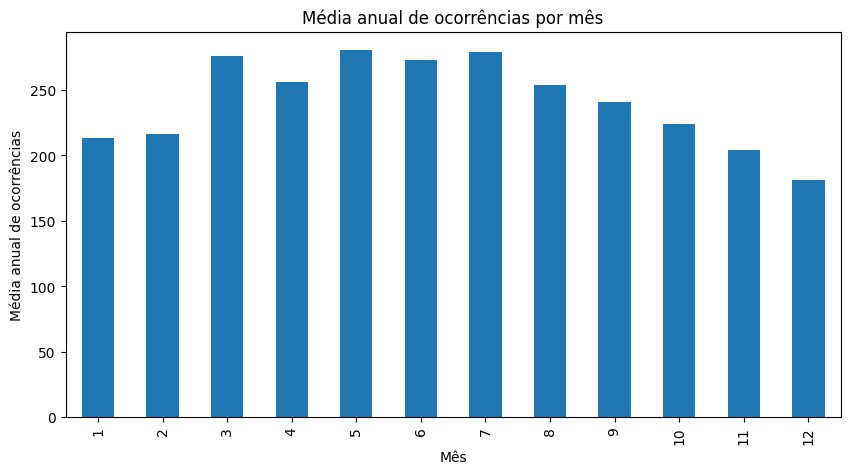

In [51]:
ocorrencias_mes = (
    fogo_cruzado_df
    .groupby("mes")
    .size()
)

# Definir o número de anos para cada mês
num_anos_por_mes = pd.Series({
    1: 10, 2: 10, 3: 10, 4: 9, 5: 9, 6: 9,
    7: 10, 8: 10, 9: 10, 10: 10, 11: 10, 12: 10
}, name='num_anos')

# Calcular a média anual por mês
ocorrencias_mes_media_anual = ocorrencias_mes.div(num_anos_por_mes)

ocorrencias_mes_media_anual.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Média anual de ocorrências por mês")
plt.xlabel("Mês")
plt.ylabel("Média anual de ocorrências")

plt.show()

In [52]:
print(ocorrencias_mes_media_anual.sort_values(ascending=False).head())

mes
5   280.3333
7   279.2000
3   275.6000
6   272.7778
4   255.8889
dtype: float64


Os meses acima são os mais perigosos em todo o período observado, pois somam as maiores ocorrências. Percebemos também uma tendêcia de diminuição da violência ao final do ano e redução no meio.

##### Quantidade de ocorrências por dia da semana em todo período

Para os dias da semana, percebemos que os dias úteisequilíbrio em relacão ao número de ocorrências, enquanto sábado e domingo possuem menos ocorrências, provavelmente por serem dias em que menos pessoas circulam nas ruas.

In [53]:
ordem = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

ocorrencias_dia = (
    fogo_cruzado_df["dia_semana"]
    .value_counts()
    .reindex(ordem)
)

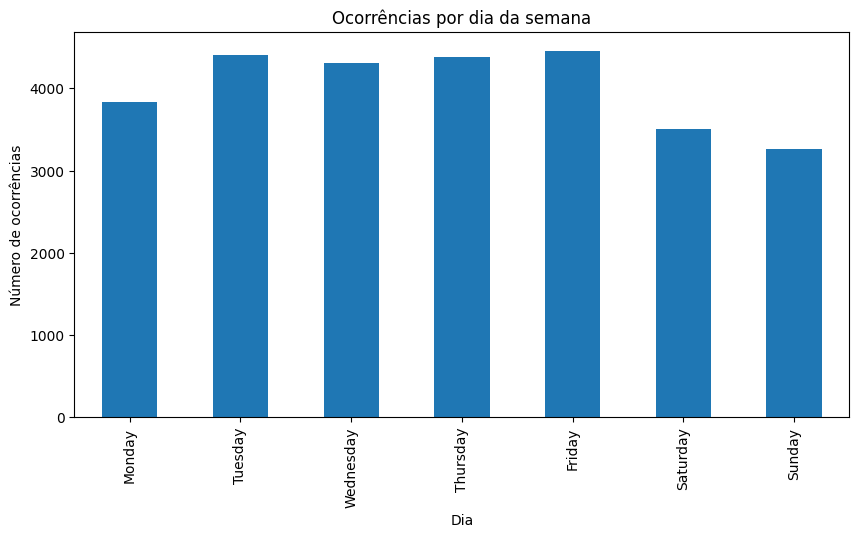

In [54]:
ocorrencias_dia.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Ocorrências por dia da semana")
plt.xlabel("Dia")
plt.ylabel("Número de ocorrências")

plt.show()

In [55]:
print(ocorrencias_dia.sort_values(ascending=False))

dia_semana
Friday       4460
Tuesday      4401
Thursday     4384
Wednesday    4309
Monday       3836
Saturday     3508
Sunday       3259
Name: count, dtype: int64


##### Quantidade de ocorrências por hora do dia em todo período

Analisamos também as ocorrências por hora do dia, percebendo que elas são maiores em partes da madrugada e da noite, se aproximando de uma distribuição bimodal.

In [56]:
ocorrencias_hora = (
    fogo_cruzado_df
    .groupby("hora")
    .size()
)

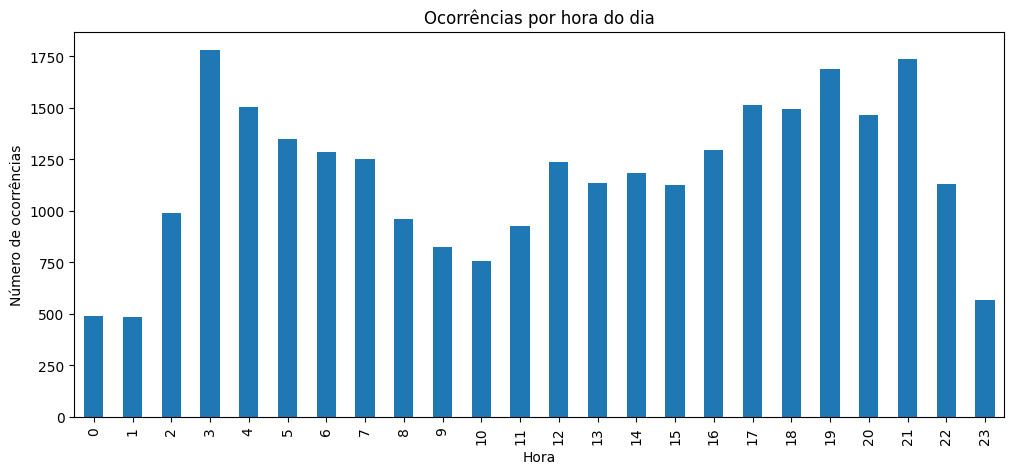

In [57]:
ocorrencias_hora = (
    fogo_cruzado_df
    .groupby("hora")
    .size()
)


plt.figure(figsize=(12,5))

ocorrencias_hora.plot(
    kind="bar"
)

plt.title("Ocorrências por hora do dia")
plt.xlabel("Hora")
plt.ylabel("Número de ocorrências")

plt.xticks(range(24))

plt.show()

In [58]:
# Horários com menos ocorrências
print(ocorrencias_hora[ocorrencias_hora < 1200].sort_values(ascending=False))

hora
14    1184
13    1133
22    1129
15    1126
2      990
8      960
11     925
9      826
10     755
23     568
0      489
1      483
dtype: int64


## Criação das Tabelas de Equivalência entre Linhas e Áreas

### Equivalência entre Linhas de Ônibus e CISPs

Precisamos construir uma tabela que, para cada linha de ônibus, diga por qual CISPs ela passa.

Uma forma de fazer isso é pegar o conjunto de pontos que compõe cada linha e verificar, para cada um deles, em qual CISP ele se encontra.

Para começar, precisamos de uma função que retorne em qual CISP uma determinada coordenada está.

In [59]:
def get_cisp_from_point(latitude, longitude):
    """
    Determina a qual CISP um ponto geográfico pertence.

    Args:
        latitude (float): A latitude do ponto.
        longitude (float): A longitude do ponto.

    Returns:
        int or None: O ID da CISP à qual o ponto pertence, ou None se não pertencer a nenhuma.
    """
    # Cria um objeto Point a partir das coordenadas
    point = Point(longitude, latitude)

    # Itera sobre cada CISP no GeoDataFrame filtrado para o município
    for index, row in cisp_df_municipio.iterrows():
        if row['geometry'] is not None and row['geometry'].contains(point):
            return row['cisp']
    return None

Testamos nossa função com alguns pontos arbitrariamente escolhidos e verificamos que eles estão na CISP esperada.

In [60]:
sample_latitude = -22.898278 # Exemplo de latitude
sample_longitude = -43.760250 # Exemplo de longitude

cisp_id = get_cisp_from_point(sample_latitude, sample_longitude)

if cisp_id:
    print(f"O ponto ({sample_latitude}, {sample_longitude}) pertence à CISP {cisp_id}")
else:
    print(f"O ponto ({sample_latitude}, {sample_longitude}) não pertence a nenhuma CISP conhecida.")

O ponto (-22.898278, -43.76025) pertence à CISP 36


Vamos então criar uma função que, para todos os pontos de uma dada linha de ônibus, obtêm as CISPs nas quais eles se localizam.

In [61]:
def get_all_cisps_for_route_shape(shape_wkt):
    """
    Extrai todas as CISPs por onde uma rota de ônibus passa, dada a geometria da rota.

    Args:
        shape_wkt (str): A representação WKT (Well-Known Text) da geometria da rota (LINESTRING ou MULTILINESTRING).

    Returns:
        list: Uma lista ordenada e única de IDs de CISPs que a rota atravessa.
    """
    geometry_obj = wkt.loads(shape_wkt)
    cisp_ids_for_route = set()

    # Helper function to extract points from any geometry type
    def extract_points(geometry):
        if geometry.geom_type == 'Point':
            yield geometry
        elif geometry.geom_type == 'LineString':
            for coord in geometry.coords:
                yield Point(coord)
        elif geometry.geom_type == 'MultiPoint':
            for point in geometry.geoms:
                yield point
        elif geometry.geom_type == 'MultiLineString':
            for line in geometry.geoms:
                for coord in line.coords:
                    yield Point(coord)
        elif geometry.geom_type == 'Polygon':
            # For a polygon, we're interested in the boundary for a route
            for coord in geometry.exterior.coords:
                yield Point(coord)
        elif geometry.geom_type == 'MultiPolygon':
            for poly in geometry.geoms:
                for coord in poly.exterior.coords:
                    yield Point(coord)

    for point_obj in extract_points(geometry_obj):
        # get_cisp_from_point expects latitude, longitude. Shapely Point is (longitude, latitude)
        cisp_id = get_cisp_from_point(point_obj.y, point_obj.x)
        if cisp_id is not None:
            cisp_ids_for_route.add(cisp_id)

    return sorted(list(cisp_ids_for_route))

Para facilitar a manipulação das linhas, vamos criar um dataframe com apenas com as colunas de geometria e nome da linha:

In [62]:
servico_shape_df = itinerarios_df[['servico', 'shape_id', 'geometry']]
print("DataFrame com as colunas 'servico', 'shape_id' e 'geometry':")


DataFrame com as colunas 'servico', 'shape_id' e 'geometry':


In [63]:
servico_shape_df.loc[servico_shape_df["servico"] == "SN415"]

,servico,shape_id,geometry
73,SN415,3f1i,"LINESTRING (-43.22348 -22.98559, -43.22349 -22..."


Vamos então testar nossa função escolhendo uma linha para extrair as CISPs.

In [64]:
first_row = servico_shape_df.iloc[15]
first_service_id = first_row['servico']
first_shape_wkt = first_row['geometry'].wkt # Convertendo o objeto geometry para WKT string

# Gerar a lista de CISPs para essa rota
cisps_for_first_service = get_all_cisps_for_route_shape(first_shape_wkt)

print(f"O serviço '{first_service_id}' passa pelas seguintes CISPs: {cisps_for_first_service}")

O serviço 'SR384' passa pelas seguintes CISPs: [1, 4, 5, 6, 9, 17, 18, 21, 22, 27, 31, 38, 39, 40]


Podemos inspecionar visualmente as CISPs atravessadas pela linha escolhida:

/tmp/ipykernel_99568/246734780.py:38: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left')


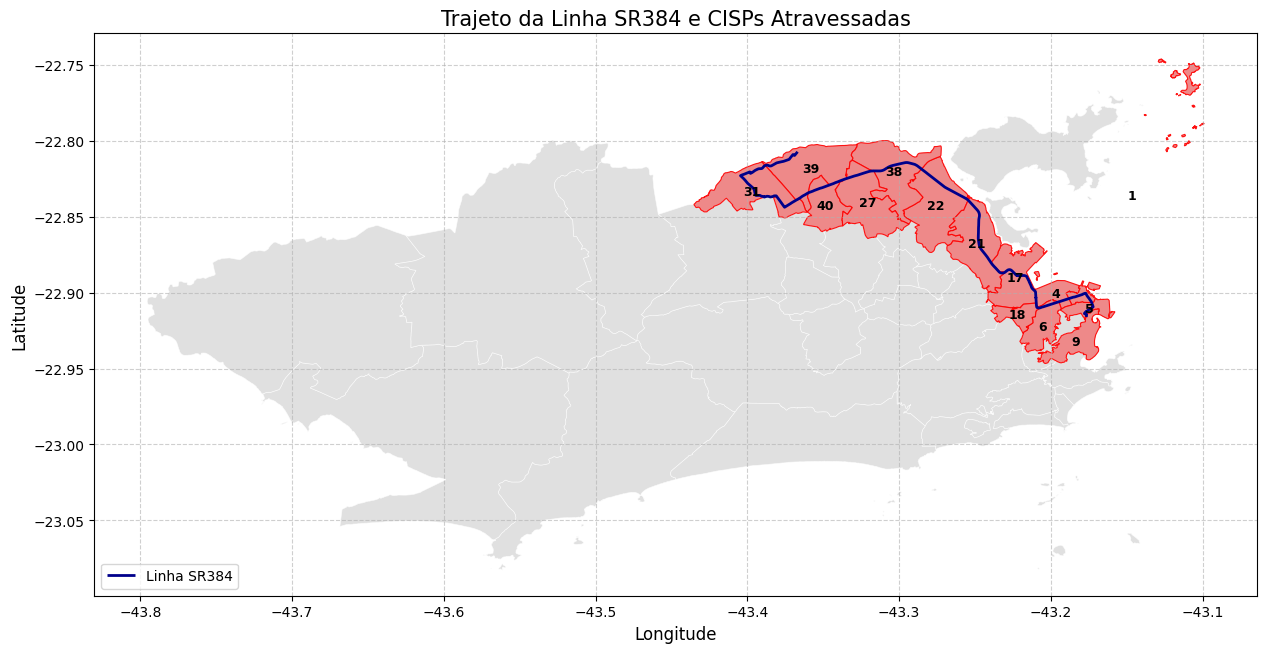

In [65]:
# Selecionar uma linha de ônibus para visualização (ex: o 'first_row' já testado)
selected_service_row = servico_shape_df.iloc[15] # Usando o mesmo índice 10 do teste anterior
selected_service_id = selected_service_row['servico']
selected_shape_wkt = selected_service_row['geometry'].wkt
selected_geometry = selected_service_row['geometry']

# Obter as CISPs por onde a linha de ônibus passa
cisps_intersected_by_route = get_all_cisps_for_route_shape(selected_shape_wkt)

# Criar a figura e eixos para o plot
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Plotar todas as CISPs do município em cinza claro como fundo
cisp_df_municipio.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5, alpha=0.7)

# Plotar as CISPs pelas quais a linha passa com uma cor diferente
cisp_df_municipio[cisp_df_municipio['cisp'].isin(cisps_intersected_by_route)].plot(
    ax=ax, color='lightcoral', edgecolor='red', linewidth=0.8, alpha=0.9, label='CISPs Atravessadas'
)

# Plotar a linha de ônibus selecionada
gpd.GeoSeries([selected_geometry]).plot(ax=ax, color='darkblue', linewidth=2, label=f'Linha {selected_service_id}')

# Adicionar o número de cada CISP (apenas para as CISPs atravessadas, ou todas se for pequeno)
for idx, row in cisp_df_municipio.iterrows():
    if row['geometry'] is not None and not row['geometry'].is_empty:
        centroid = row['geometry'].centroid
        if row['cisp'] in cisps_intersected_by_route:
            ax.text(centroid.x, centroid.y, str(row['cisp']),
                    fontsize=9, ha='center', va='center', color='black', fontweight='bold')
        # else:
        #     ax.text(centroid.x, centroid.y, str(row['cisp']),
        #             fontsize=7, ha='center', va='center', color='dimgray')

ax.set_title(f'Trajeto da Linha {selected_service_id} e CISPs Atravessadas', fontsize=15)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.legend(loc='lower left')
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [66]:
servico_shape_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 491 entries, 0 to 935
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   servico   491 non-null    object  
 1   shape_id  491 non-null    object  
 2   geometry  491 non-null    geometry
dtypes: geometry(1), object(2)
memory usage: 31.5+ KB


Podemos então construir o DataFrame com as CISPs para cada uma das linhas de ônibus do Rio de Janeiro.

In [67]:
def process_shape_for_cisps_optimized(servico_shape_df, cisp_df_municipio):
    """
    Versão otimizada usando a interseção espacial do GeoPandas para encontrar CISPs que as rotas atravessam.
    """
    # Realiza um join espacial entre as rotas de ônibus e os polígonos das CISPs
    # Isso identifica quais polígonos de CISP interceptam a geometria de cada rota.
    # O 'servico_shape_df' contém 'servico', 'shape_id' e 'geometry'
    # O 'cisp_df_municipio' contém 'cisp' (ID da CISP) e 'geometry'
    joined_cisps = gpd.sjoin(servico_shape_df, cisp_df_municipio[['cisp', 'geometry']], how='left', predicate='intersects')

    # Agrupa por 'shape_id' para coletar todas as CISPs únicas para cada rota
    # Garantir que 'cisp' é um tipo inteiro e remover NaNs antes de criar a lista de sets
    cisp_per_shape_aggregated = joined_cisps.groupby('shape_id')['cisp'].apply(
        lambda x: sorted(list(set(x.dropna().astype(int)))) if x.notna().any() else []
    ).reset_index()

    cisp_per_shape_aggregated.rename(columns={'cisp': 'cisp_ids'}, inplace=True)
    return cisp_per_shape_aggregated

print("Processando equivalência entre linhas de ônibus e CISPs de forma otimizada...")
cisp_per_shape = process_shape_for_cisps_optimized(servico_shape_df, cisp_df_municipio)

# Agora, mescle cisp_per_shape com itinerarios_df para adicionar as CISPs aos serviços
# Usamos o 'shape_id' para fazer o merge e depois agrupamos por 'servico'
itinerarios_with_cisps_details = itinerarios_df.merge(
    cisp_per_shape[['shape_id', 'cisp_ids']],
    on='shape_id',
    how='left'
)

# Agrega as cisp_ids para cada 'servico' único, remove duplicatas e ordena
linhas_cisps_df = itinerarios_with_cisps_details.groupby('servico')['cisp_ids'].apply(
    lambda x: sorted(list(set(sum((item for item in x if isinstance(item, list) and item is not None), []))))
).reset_index()

linhas_cisps_df.rename(columns={'cisp_ids': 'cisp_list'}, inplace=True)

print("DataFrame com a lista de CISPs para cada serviço de ônibus:")
linhas_cisps_df.head()

Processando equivalência entre linhas de ônibus e CISPs de forma otimizada...
DataFrame com a lista de CISPs para cada serviço de ônibus:


,servico,cisp_list
0,006,"[5, 7, 9]"
1,007,"[4, 5, 7, 9]"
2,010,"[1, 4, 5, 9]"
3,10,"[16, 36, 42, 43]"
4,100,"[1, 4, 5, 9, 10, 12, 13, 14]"


In [68]:
linhas_cisps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   servico    491 non-null    object
 1   cisp_list  491 non-null    object
dtypes: object(2)
memory usage: 7.8+ KB


### Equivalência entre linhas e bairros

Realizamos um processo semelhante para construir a equivalência entre linhas e bairros atravessados por elas:

In [69]:
def get_bairro_from_point(latitude, longitude):
    """
    Determina a qual bairro um ponto geográfico pertence.

    Args:
        latitude (float): A latitude do ponto.
        longitude (float): A longitude do ponto.

    Returns:
        str or None: O nome do bairro ao qual o ponto pertence, ou None se não pertencer a nenhum.
    """
    point = Point(longitude, latitude)

    for index, row in bairros_df.iterrows():
        if row['geometry'] is not None and row['geometry'].contains(point):
            return row['nome'] # Retorna o nome do bairro
    return None

def get_all_bairros_for_route_shape(shape_wkt):
    """
    Extrai todos os bairros por onde uma rota de ônibus passa, dada a geometria da rota.

    Args:
        shape_wkt (str): A representação WKT (Well-Known Text) da geometria da rota (LINESTRING ou MULTILINESTRING).

    Returns:
        list: Uma lista ordenada e única de nomes de bairros que a rota atravessa.
    """
    geometry_obj = wkt.loads(shape_wkt)
    bairro_names_for_route = set()

    def extract_points(geometry):
        if geometry.geom_type == 'Point':
            yield geometry
        elif geometry.geom_type == 'LineString':
            for coord in geometry.coords:
                yield Point(coord)
        elif geometry.geom_type == 'MultiPoint':
            for point in geometry.geoms:
                yield point
        elif geometry.geom_type == 'MultiLineString':
            for line in geometry.geoms:
                for coord in line.coords:
                    yield Point(coord)
        elif geometry.geom_type == 'Polygon':
            for coord in geometry.exterior.coords:
                yield Point(coord)
        elif geometry.geom_type == 'MultiPolygon':
            for poly in geometry.geoms:
                for coord in poly.exterior.coords:
                    yield Point(coord)

    for point_obj in extract_points(geometry_obj):
        bairro_name = get_bairro_from_point(point_obj.y, point_obj.x)
        if bairro_name is not None:
            bairro_names_for_route.add(bairro_name)

    return sorted(list(bairro_names_for_route))

In [70]:
def process_shape_for_bairros_optimized(servico_shape_df, bairros_df):
    """
    Versão otimizada usando a interseção espacial do GeoPandas. Retorna um dataframe com
    as linhas e os bairros que elas passam
    """
    # Realiza um join espacial entre as rotas e os bairros
    # Isso identifica quais polígonos de bairros interceptam a linha da rota
    joined = gpd.sjoin(servico_shape_df, bairros_df[['nome', 'geometry']], how='left', predicate='intersects')

    # Agrupa os nomes dos bairros por serviço
    linha_bairros = joined.groupby('servico')['nome'].apply(lambda x: sorted(list(set(x.dropna())))).reset_index()
    linha_bairros.rename(columns={'nome': 'bairros_list'}, inplace=True)
    return linha_bairros

print("Processando equivalência linha-bairro de forma otimizada...")
linhas_bairros_df = process_shape_for_bairros_optimized(servico_shape_df, bairros_df)

print("DataFrame 'linha_bairros_df' criado com sucesso.")
linhas_bairros_df.head()

Processando equivalência linha-bairro de forma otimizada...
DataFrame 'linha_bairros_df' criado com sucesso.


,servico,bairros_list
0,006,"[CENTRO, COSME VELHO, LAPA, SANTA TERESA]"
1,007,"[CENTRO, COSME VELHO, LAPA, SANTA TERESA]"
2,010,"[CENTRO, GAMBOA, GLORIA, LAPA, SAUDE]"
3,10,"[BARRA DA TIJUCA, BARRA DE GUARATIBA, GUARATIB..."
4,100,"[BOTAFOGO, CENTRO, COPACABANA, FLAMENGO, GLORI..."


In [71]:
linhas_bairros_df[linhas_bairros_df['servico'] == '905']

,servico,bairros_list
321,905,"[BONSUCESSO, BRAS DE PINA, CORDOVIL, IRAJA, OL..."


In [72]:
# Selecionar uma linha de ônibus para visualização com base no input do usuário
def show_trajeto_linha (linha: str):
  '''
    Recebe uma linha (servico) em string e plota o trajeto em um sentido dessa linha.
  '''
  linha_df = servico_shape_df[
      servico_shape_df["servico"] == linha
  ]
  if not linha_df.empty:
      selected_service_row_bairro = linha_df.iloc[0]  # Pega a primeira (e única) linha do DataFrame filtrado
      selected_service_id_bairro = selected_service_row_bairro['servico']
      selected_shape_wkt_bairro = selected_service_row_bairro['geometry'].wkt
      selected_geometry_bairro = selected_service_row_bairro['geometry']

      # Obter os bairros por onde a linha de ônibus passa
      bairros_intersected_by_route = get_all_bairros_for_route_shape(selected_shape_wkt_bairro)

      # Criar a figura e eixos para o plot
      fig, ax = plt.subplots(1, 1, figsize=(15, 15))

      # Plotar todos os bairros em cinza claro como fundo
      bairros_df.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5, alpha=0.7)

      # Plotar os bairros pelos quais a linha passa com uma cor diferente
      bairros_df[bairros_df['nome'].isin(bairros_intersected_by_route)].plot(
          ax=ax, color='lightcoral', edgecolor='red', linewidth=0.8, alpha=0.9, label='Bairros Atravessados'
      )

      # Plotar a linha de ônibus selecionada
      gpd.GeoSeries([selected_geometry_bairro]).plot(ax=ax, color='darkblue', linewidth=2, label=f'Linha {selected_service_id_bairro}')


      ax.set_title(f'Trajeto da Linha {selected_service_id_bairro} e Bairros Atravessados', fontsize=15)
      ax.set_xlabel('Longitude', fontsize=12)
      ax.set_ylabel('Latitude', fontsize=12)
      ax.legend(loc='lower left')
      ax.grid(True, linestyle='--', alpha=0.6)
      plt.show()
  else:
      print(f"A linha '{linha}' não foi encontrada no DataFrame de serviços.")

/tmp/ipykernel_99568/1935786522.py:36: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left')


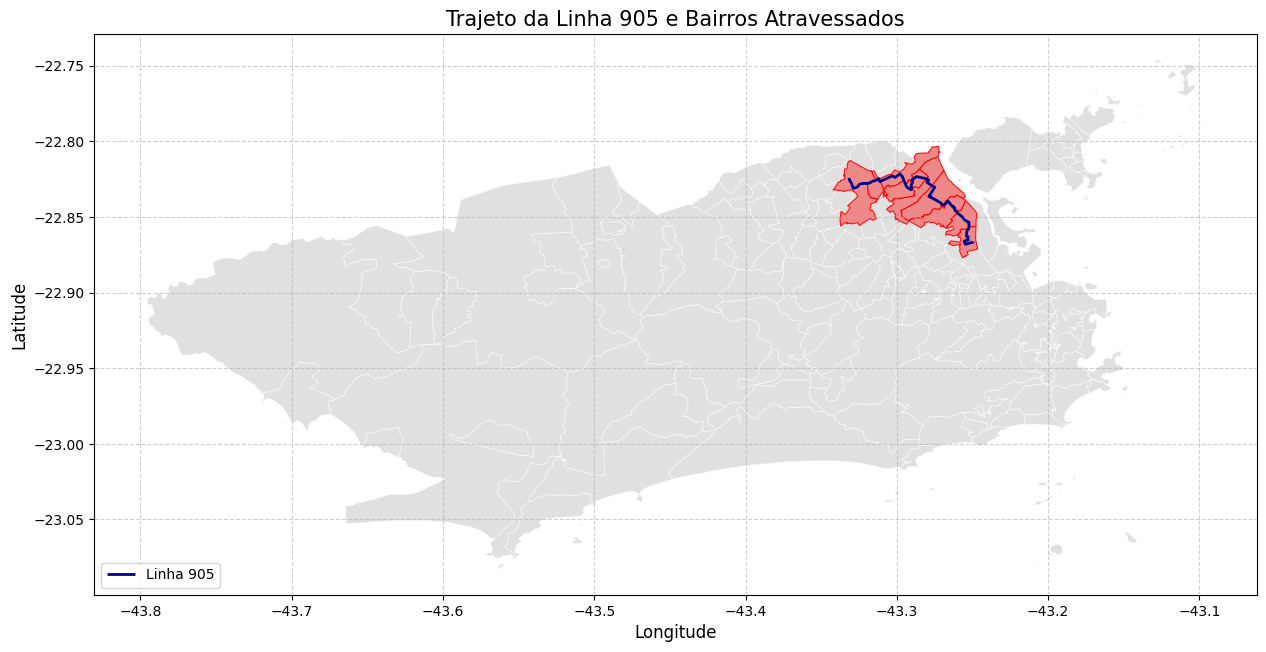

In [73]:
show_trajeto_linha('905')

## Seleção do Modelo de Regressão

### Dados do Fogo Cruzado

Iremos realizar três regressões para os três índices: violência armada, roubo em coletivo e furto em coletivo. Vamos começar com os dados de violêcia armada do Fogo Cruzado, pois possuem mais detalhamento temporal (possuem data específica, enquanto os do ISP estão mensalmente agrupados).

De início, vamos inspecionar novamente o formato de fogo_cruzado_df e linhas_bairros_df.

In [74]:
fogo_cruzado_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28157 entries, 0 to 28165
Data columns (total 38 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    28157 non-null  int64         
 1   address               28157 non-null  object        
 2   region                28157 non-null  object        
 3   state                 28157 non-null  object        
 4   city                  28157 non-null  object        
 5   neighborhood          28157 non-null  object        
 6   sub_neighborhood      159 non-null    object        
 7   locality              19873 non-null  object        
 8   latitude              28157 non-null  float64       
 9   longitude             28157 non-null  float64       
 10  data                  28157 non-null  datetime64[ns]
 11  police_action         28157 non-null  bool          
 12  agent_presence        28157 non-null  bool          
 13  police_unit          

In [75]:
linhas_bairros_df.head()

,servico,bairros_list
0,006,"[CENTRO, COSME VELHO, LAPA, SANTA TERESA]"
1,007,"[CENTRO, COSME VELHO, LAPA, SANTA TERESA]"
2,010,"[CENTRO, GAMBOA, GLORIA, LAPA, SAUDE]"
3,10,"[BARRA DA TIJUCA, BARRA DE GUARATIBA, GUARATIB..."
4,100,"[BOTAFOGO, CENTRO, COPACABANA, FLAMENGO, GLORI..."


Vamos construir uma série temporal agregando as ocorrencias em cada linha, a cada dia. Ou seja, para a linha 100 teremos uma entrada referente a ocorrências nas ultimas 24 horas por dia.

In [76]:
def construir_serie_linha_dia(
    fogo_cruzado_df,
    df_linhas,
    servico,
    datetime_col="date",
    bairro_col="neighborhood_cleaned",
    meses_recentes=117
):
    linha_info = df_linhas[df_linhas["servico"] == servico]

    if linha_info.empty:
        raise ValueError(f"Serviço {servico} não encontrado.")

    bairros_linha = linha_info.iloc[0]["bairros_list"]
    bairros_linha = [b.upper().strip() for b in bairros_linha]

    df = fogo_cruzado_df.copy()
    df[datetime_col] = pd.to_datetime(df[datetime_col])

    fim = df[datetime_col].max().floor("D")
    inicio = fim - pd.DateOffset(months=meses_recentes)

    df = df[
        (df[datetime_col] >= inicio) &
        (df[datetime_col] <= fim)
    ].copy()

    df[bairro_col] = (
        df[bairro_col]
        .astype(str)
        .str.upper()
        .str.strip()
    )

    df_linha = df[df[bairro_col].isin(bairros_linha)].copy()

    df_linha["data_base"] = df_linha[datetime_col].dt.floor("D")

    serie = (
        df_linha
        .groupby("data_base")
        .size()
        .reset_index(name="ocorrencias_dia")
    )

    todos_dias = pd.DataFrame({
        "data_base": pd.date_range(
            inicio.floor("D"),
            fim,
            freq="D"
        )
    })

    serie = todos_dias.merge(serie, on="data_base", how="left")
    serie["ocorrencias_dia"] = serie["ocorrencias_dia"].fillna(0).astype(int)

    serie.insert(0, "servico", servico)
    serie["n_bairros"] = len(bairros_linha)

    return serie

Criamos features que permitirão o treinamento do Regressor, como saber se aquele dia é em um final de semana e a soma móvel das ocorrências os últimos, 7, 14, 30, 60 e 90 dias. Essas features tentarão prever as próximas 24 horas, que é o target criado. Para criar esse target os dados são deslocados em 1 dia com shift().

In [77]:
def criar_features_target_30d(df):
    df = df.copy()

    df = df.sort_values("data_base")
    df["data_base"] = pd.to_datetime(df["data_base"])

    df["dia_semana_num"] = df["data_base"].dt.dayofweek
    df["fim_semana"] = df["dia_semana_num"].isin([5, 6]).astype(int)
    df["mes"] = df["data_base"].dt.month
    df["dia_mes"] = df["data_base"].dt.day
    df["trimestre"] = df["data_base"].dt.quarter

    serie_passada = df["ocorrencias_dia"].shift(1)

    df["rolling_7d"] = serie_passada.rolling(7).sum()
    df["rolling_14d"] = serie_passada.rolling(14).sum()
    df["rolling_30d"] = serie_passada.rolling(30).sum()
    df["rolling_60d"] = serie_passada.rolling(60).sum()
    df["rolling_90d"] = serie_passada.rolling(90).sum()


    df["tendencia_30d_vs_60d"] = (
        df["rolling_30d"] - (df["rolling_60d"] / 2)
    )

    df["tendencia_30d_vs_90d"] = (
        df["rolling_30d"] - (df["rolling_90d"] / 3)
    )

    df["atividade_relativa_30d_90d"] = (
        df["rolling_30d"] / ((df["rolling_90d"] / 3) + 1e-6)
    )

    df["atividade_relativa_14d_60d"] = (
        df["rolling_14d"] / ((df["rolling_60d"] / 4) + 1e-6)
    )

    df["target_ocorrencias_30d"] = (
        df["ocorrencias_dia"]
        .shift(-1)
        .rolling(30)
        .sum()
        .shift(-29)
    )

    df = df.dropna().reset_index(drop=True)

    return df

In [78]:
def montar_dataset_multilinhas_diario(
    fogo_cruzado_df,
    df_linhas,
    servicos,
    datetime_col="data",
    bairro_col="neighborhood_cleaned",
    meses_recentes=117
):
    partes = []

    for servico in servicos:
        try:
            serie = construir_serie_linha_dia(
                fogo_cruzado_df=fogo_cruzado_df,
                df_linhas=df_linhas,
                servico=servico,
                datetime_col=datetime_col,
                bairro_col=bairro_col,
                meses_recentes=meses_recentes
            )

            df_modelo = criar_features_target_30d(serie)

            if len(df_modelo) > 0:
                partes.append(df_modelo)

        except Exception as e:
            print(f"Erro no serviço {servico}: {e}")

    if not partes:
        raise ValueError("Nenhuma linha gerou dataset válido.")

    df_final = pd.concat(partes, ignore_index=True)
    df_final = df_final.sort_values(["data_base", "servico"]).reset_index(drop=True)

    return df_final

In [79]:
servicos_str = linhas_bairros_df["servico"].astype(str).tolist()

df_modelo = montar_dataset_multilinhas_diario(
    fogo_cruzado_df=fogo_cruzado_df,
    df_linhas=linhas_bairros_df,
    servicos=servicos_str,
    datetime_col="data",
    meses_recentes=117
)

In [80]:
df_modelo.head(10)

,servico,data_base,ocorrencias_dia,n_bairros,dia_semana_num,fim_semana,mes,dia_mes,trimestre,rolling_7d,rolling_14d,rolling_30d,rolling_60d,rolling_90d,tendencia_30d_vs_60d,tendencia_30d_vs_90d,atividade_relativa_30d_90d,atividade_relativa_14d_60d,target_ocorrencias_30d
0,006,2016-09-28,1,4,2,0,9,28,3,2.0000,4.0000,9.0000,14.0000,20.0000,2.0000,2.3333,1.3500,1.1429,19.0000
1,007,2016-09-28,1,4,2,0,9,28,3,2.0000,4.0000,9.0000,14.0000,20.0000,2.0000,2.3333,1.3500,1.1429,19.0000
2,010,2016-09-28,1,5,2,0,9,28,3,1.0000,2.0000,5.0000,8.0000,16.0000,1.0000,-0.3333,0.9375,1.0000,7.0000
3,10,2016-09-28,0,6,2,0,9,28,3,0.0000,0.0000,3.0000,9.0000,24.0000,-1.5000,-5.0000,0.3750,0.0000,1.0000
4,100,2016-09-28,1,7,2,0,9,28,3,4.0000,7.0000,20.0000,33.0000,45.0000,3.5000,5.0000,1.3333,0.8485,21.0000
5,104,2016-09-28,1,14,2,0,9,28,3,5.0000,10.0000,25.0000,40.0000,58.0000,5.0000,5.6667,1.2931,1.0000,23.0000
6,107,2016-09-28,1,5,2,0,9,28,3,1.0000,1.0000,5.0000,7.0000,11.0000,1.5000,1.3333,1.3636,0.5714,4.0000
7,11,2016-09-28,0,7,2,0,9,28,3,0.0000,0.0000,3.0000,9.0000,24.0000,-1.5000,-5.0000,0.3750,0.0000,1.0000
8,117,2016-09-28,1,6,2,0,9,28,3,2.0000,5.0000,11.0000,15.0000,23.0000,3.5000,3.3333,1.4348,1.3333,26.0000
9,12,2016-09-28,0,6,2,0,9,28,3,0.0000,0.0000,1.0000,5.0000,6.0000,-1.5000,-1.0000,0.5000,0.0000,0.0000


Após realizar a expansão do dataset com agregação por dias e introdução das features, temos o dataframe necessário para alimentar nosso Regressor.

Vamos agora explorar um pouco o target que queremos prever: a quantidade de ocorrências para uma linha no próximo mês.

In [81]:
df_modelo['target_ocorrencias_30d'].describe()

,target_ocorrencias_30d
count,1690022.0000
mean,19.6841
std,20.5048
min,0.0000
25%,5.0000
50%,13.0000
75%,27.0000
max,250.0000


<Axes: >

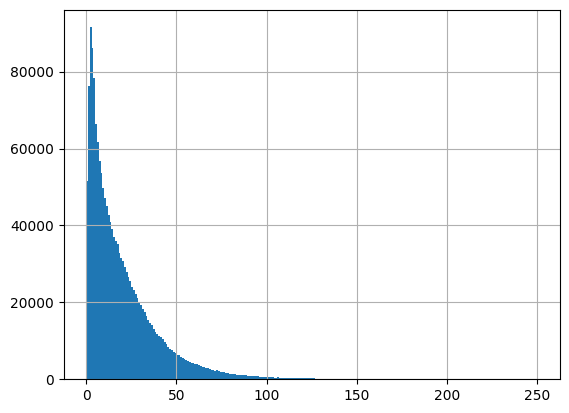

In [82]:
df_modelo['target_ocorrencias_30d'].hist(bins=250)

Observamos que a mediana de ocorrências é 13, com uma cauda longa após o pico. Vamos codificar cada linha como um inteiro para auxiliar a regressão.

In [83]:
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

df_modelo["servico_encoded"] = encoder.fit_transform(
    df_modelo[["servico"]]
)

In [84]:
features = [
    "servico_encoded",
    "n_bairros",

    "dia_semana_num",
    "fim_semana",
    "mes",
    "dia_mes",
    "trimestre",

    "rolling_7d",
    "rolling_14d",
    "rolling_30d",
    "rolling_60d",
    "rolling_90d",

    "tendencia_30d_vs_60d",
    "tendencia_30d_vs_90d",

    "atividade_relativa_30d_90d",
    "atividade_relativa_14d_60d",
]

A seguir, dividimos os dados em treino e teste, com 80% no treino e 20% no teste.

In [85]:
X = df_modelo[features]
y = df_modelo["target_ocorrencias_30d"]

data_corte = df_modelo["data_base"].quantile(0.8)

train_mask = df_modelo["data_base"] <= data_corte
test_mask = df_modelo["data_base"] > data_corte

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

Agora, vamos testar alguns modelos de regressão para avaliar qual é mais preciso. Como comparação, vamos tomar também a média dos últimos 30 dias (DummyRegressor), garantindo que os modelos estão performando melhor que apenas calcular a média.

In [86]:
modelos = {
    "Dummy - Média": DummyRegressor(strategy="mean"),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "PoissonRegressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", PoissonRegressor(alpha=1.0, max_iter=300))
    ]),

    "RandomForest" : RandomForestRegressor(
        n_estimators=30,
        max_depth=5,
        min_samples_leaf=30,
        max_features=0.5,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        loss="poisson",
        max_iter=150,
        learning_rate=0.05,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=42
    ),

    "XGBoost Poisson": XGBRegressor(
        objective="count:poisson",
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_alpha=0.2,
        reg_lambda=2.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    )
}

In [87]:
def avaliar_modelo(nome, modelo, X_train, y_train, X_test, y_test):
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    # como estamos prevendo contagem, não faz sentido previsão negativa
    y_pred = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {
        "modelo": nome,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [88]:
resultados = []

for nome, modelo in modelos.items():

    print(f"\nTreinando modelo: {nome}")

    inicio = time.time()

    resultado = avaliar_modelo(
        nome,
        modelo,
        X_train,
        y_train,
        X_test,
        y_test
    )

    fim = time.time()

    tempo_total = fim - inicio

    resultado["tempo_segundos"] = tempo_total

    resultados.append(resultado)

    print(
        f"Concluído | "
        f"MAE: {resultado['MAE']:.4f} | "
        f"RMSE: {resultado['RMSE']:.4f} | "
        f"R²: {resultado['R2']:.4f} | "
        f"Tempo: {tempo_total:.2f}s"
    )

df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values("MAE")

print("\n=== Ranking final ===")

df_resultados


Treinando modelo: Dummy - Média
Concluído | MAE: 13.0708 | RMSE: 14.5971 | R²: -1.1049 | Tempo: 0.02s

Treinando modelo: Ridge
Concluído | MAE: 4.3150 | RMSE: 6.0629 | R²: 0.6369 | Tempo: 1.22s

Treinando modelo: PoissonRegressor
Concluído | MAE: 6.5719 | RMSE: 7.8253 | R²: 0.3951 | Tempo: 4.08s

Treinando modelo: RandomForest
Concluído | MAE: 3.9841 | RMSE: 5.8934 | R²: 0.6569 | Tempo: 61.28s

Treinando modelo: HistGradientBoosting
Concluído | MAE: 3.9973 | RMSE: 5.8785 | R²: 0.6586 | Tempo: 37.90s

Treinando modelo: XGBoost Poisson
Concluído | MAE: 4.0148 | RMSE: 5.8764 | R²: 0.6589 | Tempo: 24.43s

=== Ranking final ===


,modelo,MAE,RMSE,R2,tempo_segundos
3,RandomForest,3.9841,5.8934,0.6569,61.2773
4,HistGradientBoosting,3.9973,5.8785,0.6586,37.9046
5,XGBoost Poisson,4.0148,5.8764,0.6589,24.4328
1,Ridge,4.3150,6.0629,0.6369,1.2202
2,PoissonRegressor,6.5719,7.8253,0.3951,4.0817
0,Dummy - Média,13.0708,14.5971,-1.1049,0.0226


#### Fine Tuning do Random Forest

Os resultados acima permitem concluir que o RandomForest apresenta menor erro médio e maior R, apesar de ser o modelo que leva mais tempo para ser executado. Vamos tentar ajustar os parâmetros do RandomForest para melhorar ainda mais esse resultado, tomando o cuidado de não aumentar muito o número de estimadores ou fazer um GridSearch muito extenso para que o tempo de execução não exploda.

In [89]:
param_dist_rf = {
    "n_estimators": [20, 30],
    "max_depth": [4, 5, 6, 8],
    "min_samples_leaf": [10, 20, 30, 50],
    "min_samples_split": [10, 20, 40],
    "max_features": ["sqrt", 0.3, 0.5],
    "bootstrap": [True],
}

In [90]:
configs_rf = list(ParameterSampler(
    param_dist_rf,
    n_iter=15,
    random_state=42
))

In [91]:
resultados_rf = []

for i, params in enumerate(configs_rf, start=1):
    print(f"\nTreinando RandomForest {i}/{len(configs_rf)}")
    print(params)

    inicio = time.time()

    modelo_rf = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **params
    )

    modelo_rf.fit(X_train, y_train)

    y_pred = modelo_rf.predict(X_test)
    y_pred = np.maximum(y_pred, 0)

    tempo = time.time() - inicio

    resultado = {
        "config": i,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "tempo_segundos": tempo,
        **params
    }

    resultados_rf.append(resultado)

    print(
        f"Concluído | "
        f"MAE: {resultado['MAE']:.4f} | "
        f"RMSE: {resultado['RMSE']:.4f} | "
        f"R²: {resultado['R2']:.4f} | "
        f"Tempo: {tempo:.2f}s"
    )

df_tuning_rf = pd.DataFrame(resultados_rf).sort_values("MAE")
df_tuning_rf


Treinando RandomForest 1/15
{'n_estimators': 30, 'min_samples_split': 20, 'min_samples_leaf': 50, 'max_features': 0.3, 'max_depth': 4, 'bootstrap': True}
Concluído | MAE: 4.0995 | RMSE: 5.8265 | R²: 0.6646 | Tempo: 27.47s

Treinando RandomForest 2/15
{'n_estimators': 30, 'min_samples_split': 10, 'min_samples_leaf': 30, 'max_features': 'sqrt', 'max_depth': 6, 'bootstrap': True}
Concluído | MAE: 3.9474 | RMSE: 5.7638 | R²: 0.6718 | Tempo: 41.34s

Treinando RandomForest 3/15
{'n_estimators': 20, 'min_samples_split': 40, 'min_samples_leaf': 30, 'max_features': 0.3, 'max_depth': 8, 'bootstrap': True}
Concluído | MAE: 3.9580 | RMSE: 5.8421 | R²: 0.6628 | Tempo: 35.33s

Treinando RandomForest 4/15
{'n_estimators': 20, 'min_samples_split': 10, 'min_samples_leaf': 50, 'max_features': 0.3, 'max_depth': 4, 'bootstrap': True}
Concluído | MAE: 4.1039 | RMSE: 5.8198 | R²: 0.6654 | Tempo: 18.50s

Treinando RandomForest 5/15
{'n_estimators': 30, 'min_samples_split': 10, 'min_samples_leaf': 30, 'max_f

,config,MAE,RMSE,R2,tempo_segundos,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,bootstrap
1,2,3.9474,5.7638,0.6718,41.3400,30,10,30,sqrt,6,True
4,5,3.9474,5.7638,0.6718,42.3590,30,10,30,0.3000,6,True
7,8,3.9560,5.7572,0.6726,26.8238,20,40,10,0.3000,6,True
10,11,3.9572,5.8373,0.6634,33.9143,20,10,20,sqrt,8,True
2,3,3.9580,5.8421,0.6628,35.3295,20,40,30,0.3000,8,True
9,10,3.9799,5.9117,0.6548,69.8331,30,20,10,0.5000,6,True
13,14,3.9805,5.9007,0.6560,89.5156,30,20,30,0.5000,8,True
8,9,4.0026,5.8011,0.6676,35.9547,30,40,10,sqrt,5,True
12,13,4.0049,5.7895,0.6689,21.5486,20,20,50,0.3000,5,True
14,15,4.0356,5.8890,0.6574,32.8832,20,20,20,0.5000,4,True


Verificamos que, no melhor modelo, foi possível alcançar um MAE de 3,9474, ligeiramente melhor que o original de 3,9841. Vamos aplicar esse novo modelo ao nosso conjunto de dados

In [92]:
melhor_resultado = df_tuning_rf.iloc[0]
#melhor_resultado = {"config":2, "MAE":3.9474, "RMSE":5.7638, "R2":0.6718, "tempo_segundos":39.4771, "n_estimators":30,
#                    "min_samples_split":10, "min_samples_leaf":30, "max_features":"sqrt", "max_depth":6,
#                    "bootstrap":True}


print("Melhor RandomForest encontrado no teste:")
print(f"MAE: {melhor_resultado['MAE']:.4f}")
print(f"RMSE: {melhor_resultado['RMSE']:.4f}")
print(f"R²: {melhor_resultado['R2']:.4f}")
print(f"Tempo: {melhor_resultado['tempo_segundos']:.2f}s")

melhores_params = {
    "n_estimators": int(melhor_resultado["n_estimators"]),
    "max_depth": int(melhor_resultado["max_depth"]),
    "min_samples_leaf": int(melhor_resultado["min_samples_leaf"]),
    "min_samples_split": int(melhor_resultado["min_samples_split"]),
    "max_features": melhor_resultado["max_features"],
    "bootstrap": bool(melhor_resultado["bootstrap"]),
}

modelo_final_rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    **melhores_params
)

modelo_final_rf.fit(X, y)

print("\nModelo final treinado com todos os dados de X e y.")
print("Parâmetros finais:")
print(melhores_params)

Melhor RandomForest encontrado no teste:
MAE: 3.9474
RMSE: 5.7638
R²: 0.6718
Tempo: 41.34s

Modelo final treinado com todos os dados de X e y.
Parâmetros finais:
{'n_estimators': 30, 'max_depth': 6, 'min_samples_leaf': 30, 'min_samples_split': 10, 'max_features': 'sqrt', 'bootstrap': True}


#### Previsão para linha específica

In [93]:
def criar_features_30d_sem_target(df):
    df = df.copy()

    df = df.sort_values("data_base")
    df["data_base"] = pd.to_datetime(df["data_base"])

    df["dia_semana_num"] = df["data_base"].dt.dayofweek
    df["fim_semana"] = df["dia_semana_num"].isin([5, 6]).astype(int)
    df["mes"] = df["data_base"].dt.month
    df["dia_mes"] = df["data_base"].dt.day
    df["trimestre"] = df["data_base"].dt.quarter

    serie_passada = df["ocorrencias_dia"].shift(1)

    df["rolling_7d"] = serie_passada.rolling(7).sum()
    df["rolling_14d"] = serie_passada.rolling(14).sum()
    df["rolling_30d"] = serie_passada.rolling(30).sum()
    df["rolling_60d"] = serie_passada.rolling(60).sum()
    df["rolling_90d"] = serie_passada.rolling(90).sum()

    df["tendencia_30d_vs_60d"] = (
        df["rolling_30d"] - (df["rolling_60d"] / 2)
    )

    df["tendencia_30d_vs_90d"] = (
        df["rolling_30d"] - (df["rolling_90d"] / 3)
    )

    df["atividade_relativa_30d_90d"] = (
        df["rolling_30d"] / ((df["rolling_90d"] / 3) + 1e-6)
    )

    df["atividade_relativa_14d_60d"] = (
        df["rolling_14d"] / ((df["rolling_60d"] / 4) + 1e-6)
    )

    df = df.dropna().reset_index(drop=True)

    return df

In [94]:
def prever_linha_proximos_30d(
    servico,
    fogo_cruzado_df,
    df_linhas,
    modelo,
    encoder,
    features,
    datetime_col="data",
    bairro_col="neighborhood_cleaned",
    meses_recentes=117
):
    serie = construir_serie_linha_dia(
        fogo_cruzado_df=fogo_cruzado_df,
        df_linhas=df_linhas,
        servico=servico,
        datetime_col=datetime_col,
        bairro_col=bairro_col,
        meses_recentes=meses_recentes
    )

    if serie.empty:
        raise ValueError(f"Série vazia para o serviço {servico}.")

    ultima_data = serie["data_base"].max()
    proxima_data = ultima_data + pd.Timedelta(days=1)

    nova_linha = pd.DataFrame([{
        "servico": str(servico),
        "data_base": proxima_data,
        "ocorrencias_dia": np.nan,
        "n_bairros": serie["n_bairros"].iloc[-1]
    }])

    serie_futura = pd.concat([serie, nova_linha], ignore_index=True)

    df_features = criar_features_30d_sem_target(serie_futura)

    if df_features.empty:
        raise ValueError(f"Não foi possível gerar features para o serviço {servico}.")

    ultima_linha = df_features.sort_values("data_base").iloc[-1:].copy()

    ultima_linha["servico_encoded"] = encoder.transform(
        ultima_linha[["servico"]]
    )

    X_pred = ultima_linha[features]

    previsao = modelo.predict(X_pred)[0]
    previsao = max(previsao, 0)

    return {
        "servico": str(servico),
        "data_base": proxima_data,
        "periodo_previsto_inicio": proxima_data,
        "periodo_previsto_fim": proxima_data + pd.Timedelta(days=29),
        "previsao_ocorrencias_30d": round(previsao, 2)
    }

In [95]:
resultado_tiroteio = prever_linha_proximos_30d(
    servico="388",
    fogo_cruzado_df=fogo_cruzado_df,
    df_linhas=linhas_bairros_df,
    modelo=modelo_final_rf,
    encoder=encoder,
    features=features,
    datetime_col="data",
    bairro_col="neighborhood_cleaned",
    meses_recentes=117
)

resultado_tiroteio

{'servico': '388',
 'data_base': Timestamp('2026-04-01 00:00:00'),
 'periodo_previsto_inicio': Timestamp('2026-04-01 00:00:00'),
 'periodo_previsto_fim': Timestamp('2026-04-30 00:00:00'),
 'previsao_ocorrencias_30d': np.float64(27.28)}

Por fim, vamos construir um código para prever especificamente os próximos 30 dias de uma linha com base numa determinada data.

### ML com dados do ISP

#### Roubo a Coletivo

Vamos seguir um fluxo semelhante para fazer as regressões com dados do ISP. Primeiro, vamos recordar o formato dos dataframes envolvidos:

In [96]:
linhas_cisps_df.head()

,servico,cisp_list
0,006,"[5, 7, 9]"
1,007,"[4, 5, 7, 9]"
2,010,"[1, 4, 5, 9]"
3,10,"[16, 36, 42, 43]"
4,100,"[1, 4, 5, 9, 10, 12, 13, 14]"


In [97]:
roubo_coletivo_isp_df.head(11)

,Unnamed: 0,jan,fev,mar,abr,mai,jun,jul,ago,set,out,nov,dez,total,Dif,Dif_perc,cisp
0,2016,NaN,NaN,NaN,12.0000,10.0000,19.0000,21.0000,27.0000,22.0000,22.0000,29.0000,31.0000,193,NaN,NaN,34
1,2017,9.0000,4.0000,15.0000,23.0000,27.0000,45.0000,38.0000,33.0000,30.0000,17.0000,20.0000,31.0000,292,99.0000,"51,3",34
2,2018,27.0000,29.0000,25.0000,25.0000,34.0000,30.0000,54.0000,24.0000,31.0000,27.0000,35.0000,33.0000,374,82.0000,"28,08",34
3,2019,36.0000,14.0000,10.0000,48.0000,39.0000,24.0000,27.0000,51.0000,38.0000,25.0000,33.0000,44.0000,389,15.0000,"4,01",34
4,2020,32.0000,32.0000,25.0000,25.0000,20.0000,22.0000,15.0000,15.0000,5.0000,16.0000,13.0000,18.0000,238,-151.0000,"-38,82",34
5,2021,31.0000,43.0000,43.0000,27.0000,37.0000,38.0000,28.0000,18.0000,25.0000,23.0000,19.0000,14.0000,346,108.0000,"45,38",34
6,2022,16.0000,10.0000,10.0000,8.0000,8.0000,14.0000,13.0000,4.0000,9.0000,8.0000,15.0000,12.0000,127,-219.0000,"-63,29",34
7,2023,4.0000,8.0000,6.0000,9.0000,6.0000,9.0000,27.0000,31.0000,22.0000,13.0000,18.0000,9.0000,162,35.0000,"27,56",34
8,2024,9.0000,9.0000,7.0000,9.0000,11.0000,15.0000,7.0000,12.0000,23.0000,16.0000,4.0000,15.0000,137,-25.0000,"-15,43",34
9,2025,22.0000,9.0000,4.0000,11.0000,6.0000,2.0000,1.0000,4.0000,9.0000,5.0000,2.0000,0.0000,75,-62.0000,"-45,26",34


Então, precisamos transformar os dados para longos buscando trabalhar melhor com séries temporais:

In [98]:
isp_roubo_longo = transformar_isp_para_longo(
    roubo_coletivo_isp_df,
    nome_indicador="roubo_coletivo"
)

Vamos seguir passos bem parecidos com a construção da regressão do Fogo Cruzado com a comparaçao de modelos e posterior ajuste dos parâmetros do modelo de melhor resultado.

In [99]:
def construir_serie_mensal_linha_isp(
    isp_longo,
    linhas_cisps_df,
    servico,
    indicador="roubo_coletivo",
    col_cisp="cisp"
):
    linha_info = linhas_cisps_df[
        linhas_cisps_df["servico"].astype(str) == str(servico)
    ]

    if linha_info.empty:
        raise ValueError(f"Serviço {servico} não encontrado.")

    cisps_linha = linha_info.iloc[0]["cisp_list"]
    cisps_linha = list(set(int(c) for c in cisps_linha))

    df = isp_longo.copy()
    df[col_cisp] = df[col_cisp].astype(int)

    df_linha = df[df[col_cisp].isin(cisps_linha)].copy()

    serie = (
        df_linha
        .groupby("data_mes")[indicador]
        .sum()
        .reset_index(name=f"{indicador}_mes")
    )

    inicio = serie["data_mes"].min()
    fim = serie["data_mes"].max()

    todos_meses = pd.DataFrame({
        "data_mes": pd.date_range(inicio, fim, freq="MS")
    })

    serie = todos_meses.merge(serie, on="data_mes", how="left")
    serie[f"{indicador}_mes"] = serie[f"{indicador}_mes"].fillna(0)

    serie.insert(0, "servico", str(servico))
    serie["n_cisps"] = len(cisps_linha)

    return serie

In [100]:
def criar_dataset_mensal_proximo_mes(
    serie,
    indicador="roubo_coletivo",
    remover_sem_target=True,
    features_for_dropna=None
):
    df = serie.copy()

    col_valor = f"{indicador}_mes"

    df = df.sort_values("data_mes").copy()
    df["data_mes"] = pd.to_datetime(df["data_mes"])

    df["mes"] = df["data_mes"].dt.month
    df["ano"] = df["data_mes"].dt.year
    df["trimestre"] = df["data_mes"].dt.quarter

    serie_passada = df[col_valor].shift(1)

    df["lag_1m"] = df[col_valor].shift(1)
    df["lag_2m"] = df[col_valor].shift(2)
    df["lag_3m"] = df[col_valor].shift(3)
    df["lag_6m"] = df[col_valor].shift(6)
    df["lag_12m"] = df[col_valor].shift(12)

    df["rolling_3m"] = serie_passada.rolling(3).sum()
    df["rolling_6m"] = serie_passada.rolling(6).sum()
    df["rolling_12m"] = serie_passada.rolling(12).sum()
    df["rolling_24m"] = serie_passada.rolling(24).sum()

    df["tendencia_3m_vs_12m"] = df["rolling_3m"] - (df["rolling_12m"] / 4)
    df["tendencia_6m_vs_12m"] = df["rolling_6m"] - (df["rolling_12m"] / 2)

    df["atividade_relativa_3m_12m"] = (
        df["rolling_3m"] / ((df["rolling_12m"] / 4) + 1e-6)
    )

    df["atividade_relativa_6m_12m"] = (
        df["rolling_6m"] / ((df["rolling_12m"] / 2) + 1e-6)
    )

    df["target_proximo_mes"] = df[col_valor].shift(-1)

    if features_for_dropna is not None:
        df = df.dropna(
            subset=features_for_dropna,
            how="any"
        ).reset_index(drop=True)
    else:
        all_features = [
            "n_cisps",
            "mes",
            "ano",
            "trimestre",
            "lag_1m",
            "lag_2m",
            "lag_3m",
            "lag_6m",
            "lag_12m",
            "rolling_3m",
            "rolling_6m",
            "rolling_12m",
            "rolling_24m",
            "tendencia_3m_vs_12m",
            "tendencia_6m_vs_12m",
            "atividade_relativa_3m_12m",
            "atividade_relativa_6m_12m",
            "target_proximo_mes"
        ]

        df = df.dropna(
            subset=[col for col in all_features if col in df.columns],
            how="any"
        ).reset_index(drop=True)

    if remover_sem_target:
        df = df.dropna(
            subset=["target_proximo_mes"]
        ).reset_index(drop=True)

    return df

In [101]:
def montar_dataset_multilinhas_mensal_isp(
    isp_longo,
    linhas_cisps_df,
    servicos,
    indicador="roubo_coletivo",
    features_for_dropna=None
):
    partes = []

    for servico in servicos:
        try:
            serie = construir_serie_mensal_linha_isp(
                isp_longo=isp_longo,
                linhas_cisps_df=linhas_cisps_df,
                servico=servico,
                indicador=indicador
            )

            df_modelo_linha = criar_dataset_mensal_proximo_mes(
                serie=serie,
                indicador=indicador,
                features_for_dropna=features_for_dropna
            )

            if len(df_modelo_linha) > 0:
                partes.append(df_modelo_linha)

        except Exception as e:
            print(f"Erro no serviço {servico}: {e}")

    if not partes:
        raise ValueError("Nenhuma linha gerou dataset válido.")

    df_final = pd.concat(partes, ignore_index=True)

    df_final = (
        df_final
        .sort_values(["data_mes", "servico"])
        .reset_index(drop=True)
    )

    return df_final

In [102]:
features_roubo = [
    "n_cisps",

    "mes",
    "ano",
    "trimestre",

    "lag_1m",
    "lag_2m",
    "lag_3m",
    "lag_6m",
    "lag_12m",

    "rolling_3m",
    "rolling_6m",
    "rolling_12m",
    "rolling_24m",

    "tendencia_3m_vs_12m",
    "tendencia_6m_vs_12m",

    "atividade_relativa_3m_12m",
    "atividade_relativa_6m_12m",
]

In [103]:
servicos_str = linhas_cisps_df["servico"].astype(str).unique().tolist()

df_modelo_roubo = montar_dataset_multilinhas_mensal_isp(
    isp_longo=isp_roubo_longo,
    linhas_cisps_df=linhas_cisps_df,
    servicos=servicos_str,
    indicador="roubo_coletivo",
    features_for_dropna=features_roubo
)

df_modelo_roubo.head()

,servico,data_mes,roubo_coletivo_mes,n_cisps,mes,ano,trimestre,lag_1m,lag_2m,lag_3m,...,lag_12m,rolling_3m,rolling_6m,rolling_12m,rolling_24m,tendencia_3m_vs_12m,tendencia_6m_vs_12m,atividade_relativa_3m_12m,atividade_relativa_6m_12m,target_proximo_mes
0,006,2018-04-01,18.0000,3,4,2018,2,18.0000,18.0000,18.0000,...,33.0000,54.0000,106.0000,240.0000,515.0000,-6.0000,-14.0000,0.9000,0.8833,20.0000
1,007,2018-04-01,35.0000,4,4,2018,2,35.0000,29.0000,21.0000,...,71.0000,85.0000,173.0000,438.0000,1217.0000,-24.5000,-46.0000,0.7763,0.7900,37.0000
2,010,2018-04-01,34.0000,4,4,2018,2,34.0000,34.0000,26.0000,...,77.0000,94.0000,188.0000,471.0000,1281.0000,-23.7500,-47.5000,0.7983,0.7983,42.0000
3,10,2018-04-01,58.0000,4,4,2018,2,73.0000,47.0000,39.0000,...,64.0000,159.0000,350.0000,798.0000,1247.0000,-40.5000,-49.0000,0.7970,0.8772,64.0000
4,100,2018-04-01,48.0000,8,4,2018,2,49.0000,54.0000,45.0000,...,111.0000,148.0000,288.0000,763.0000,1832.0000,-42.7500,-93.5000,0.7759,0.7549,65.0000


In [104]:
encoder_roubo = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

df_modelo_roubo["servico_encoded"] = encoder_roubo.fit_transform(
    df_modelo_roubo[["servico"]]
)

In [105]:
df_modelo_roubo = df_modelo_roubo.sort_values("data_mes").copy()

X_roubo = df_modelo_roubo[features_roubo]
y_roubo = df_modelo_roubo["target_proximo_mes"]

data_corte = df_modelo_roubo["data_mes"].quantile(0.8)

train_mask = df_modelo_roubo["data_mes"] <= data_corte
test_mask = df_modelo_roubo["data_mes"] > data_corte

X_train_roubo = X_roubo[train_mask]
X_test_roubo = X_roubo[test_mask]

y_train_roubo = y_roubo[train_mask]
y_test_roubo = y_roubo[test_mask]

In [106]:
modelos_roubo = {
    "Dummy": DummyRegressor(strategy="mean"),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Poisson": Pipeline([
        ("scaler", StandardScaler()),
        ("model", PoissonRegressor(
            alpha=10,
            max_iter=1000
        ))
    ]),

    "RandomForest": RandomForestRegressor(
        n_estimators=30,
        max_depth=6,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        loss="poisson",
        max_iter=150,
        learning_rate=0.05,
        max_leaf_nodes=15,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        objective="count:poisson",
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    )
}

In [107]:
def avaliar_modelo(
    nome,
    modelo,
    X_train,
    y_train,
    X_test,
    y_test
):
    inicio = time.time()

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_pred = np.maximum(y_pred, 0)

    tempo = time.time() - inicio

    return {
        "modelo": nome,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "tempo_segundos": tempo
    }

In [108]:
resultados_roubo = []

for nome, modelo in modelos_roubo.items():

    print(f"\nTreinando modelo: {nome}")

    resultado = avaliar_modelo(
        nome,
        modelo,
        X_train_roubo,
        y_train_roubo,
        X_test_roubo,
        y_test_roubo
    )

    resultados_roubo.append(resultado)

    print(
        f"Concluído | "
        f"MAE: {resultado['MAE']:.4f} | "
        f"RMSE: {resultado['RMSE']:.4f} | "
        f"R²: {resultado['R2']:.4f} | "
        f"Tempo: {resultado['tempo_segundos']:.2f}s"
    )

df_resultados_roubo = (
    pd.DataFrame(resultados_roubo)
    .sort_values("MAE")
)

df_resultados_roubo


Treinando modelo: Dummy
Concluído | MAE: 65.7697 | RMSE: 75.4167 | R²: -0.6834 | Tempo: 0.00s

Treinando modelo: Ridge
Concluído | MAE: 20.1937 | RMSE: 37.0666 | R²: 0.5934 | Tempo: 0.03s

Treinando modelo: Poisson
Concluído | MAE: 23.7683 | RMSE: 38.0618 | R²: 0.5712 | Tempo: 0.28s

Treinando modelo: RandomForest
Concluído | MAE: 23.0937 | RMSE: 39.6187 | R²: 0.5354 | Tempo: 1.09s

Treinando modelo: HistGradientBoosting
Concluído | MAE: 33.6130 | RMSE: 52.5900 | R²: 0.1814 | Tempo: 1.17s

Treinando modelo: XGBoost
Concluído | MAE: 26.9475 | RMSE: 43.2484 | R²: 0.4464 | Tempo: 0.75s


,modelo,MAE,RMSE,R2,tempo_segundos
1,Ridge,20.1937,37.0666,0.5934,0.0265
3,RandomForest,23.0937,39.6187,0.5354,1.0922
2,Poisson,23.7683,38.0618,0.5712,0.2838
5,XGBoost,26.9475,43.2484,0.4464,0.7535
4,HistGradientBoosting,33.6130,52.5900,0.1814,1.1692
0,Dummy,65.7697,75.4167,-0.6834,0.0024


In [109]:
melhor_modelo_nome = df_resultados_roubo.iloc[0]["modelo"]

print("Melhor modelo:")
print(melhor_modelo_nome)

Melhor modelo:
Ridge


##### Fine Tuning do Ridge

Verificamos que o melhor MAE é obtido com alpha=200, por isso adotaremos esse valor.

In [110]:
alphas = [
    0.0001, 0.001, 0.01, 0.1,
    0.5, 1, 2, 5, 10,
    20, 50, 100, 200, 500, 1000
]

resultados_ridge = []

for alpha in alphas:
    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])

    inicio = time.time()

    modelo.fit(X_train_roubo, y_train_roubo)

    y_pred = modelo.predict(X_test_roubo)
    y_pred = np.maximum(y_pred, 0)

    tempo = time.time() - inicio

    resultados_ridge.append({
        "alpha": alpha,
        "MAE": mean_absolute_error(y_test_roubo, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_roubo, y_pred)),
        "R2": r2_score(y_test_roubo, y_pred),
        "tempo_segundos": tempo
    })

df_tuning_ridge = (
    pd.DataFrame(resultados_ridge)
    .sort_values("MAE")
)

df_tuning_ridge

,alpha,MAE,RMSE,R2,tempo_segundos
12,200.0000,20.1608,36.8747,0.5976,0.0232
11,100.0000,20.1688,36.9597,0.5957,0.0231
13,500.0000,20.1720,36.6988,0.6014,0.0252
10,50.0000,20.1783,37.0103,0.5946,0.0228
9,20.0000,20.1866,37.0439,0.5939,0.0227
8,10.0000,20.1902,37.0557,0.5936,0.0225
7,5.0000,20.1921,37.0617,0.5935,0.0228
6,2.0000,20.1933,37.0654,0.5934,0.0229
5,1.0000,20.1937,37.0666,0.5934,0.0258
4,0.5000,20.1939,37.0672,0.5933,0.0224


In [111]:
melhor_alpha_ridge = df_tuning_ridge.iloc[0]["alpha"]

print("Melhor alpha:", melhor_alpha_ridge)
print("MAE:", df_tuning_ridge.iloc[0]["MAE"])
print("RMSE:", df_tuning_ridge.iloc[0]["RMSE"])
print("R²:", df_tuning_ridge.iloc[0]["R2"])

Melhor alpha: 200.0
MAE: 20.16083730263647
RMSE: 36.87467987604014
R²: 0.5975566524291679


In [112]:
modelo_ridge_roubo_final = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=melhor_alpha_ridge))
])

modelo_ridge_roubo_final.fit(X_roubo, y_roubo)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', Ridge(alpha=np.float64(200.0)))])

##### Previsão para linha específica

In [113]:
def prever_roubos_proximo_mes(
    servico,
    isp_longo,
    linhas_cisps_df,
    modelo,
    encoder,
    features,
    indicador="roubo_coletivo"
):
    serie = construir_serie_mensal_linha_isp(
        isp_longo=isp_longo,
        linhas_cisps_df=linhas_cisps_df,
        servico=servico,
        indicador=indicador
    ).sort_values("data_mes")

    col_valor = f"{indicador}_mes"

    proximo_mes = serie["data_mes"].max() + pd.DateOffset(months=1)

    nova_linha = pd.DataFrame([{
        "servico": str(servico),
        "data_mes": proximo_mes,
        col_valor: np.nan,
        "n_cisps": serie["n_cisps"].iloc[-1]
    }])

    serie_futura = pd.concat([serie, nova_linha], ignore_index=True)

    df_pred = criar_dataset_mensal_proximo_mes(
        serie=serie_futura,
        indicador=indicador,
        remover_sem_target=False,
        features_for_dropna=features_roubo
    )

    ultima_linha = df_pred.sort_values("data_mes").iloc[-1:].copy()

    ultima_linha["servico_encoded"] = encoder.transform(
        ultima_linha[["servico"]]
    )

    X_pred = ultima_linha[features]

    previsao = modelo.predict(X_pred)[0]
    previsao = max(previsao, 0)

    return {
        "servico": str(servico),
        "mes_previsto": proximo_mes.strftime("%Y-%m"),
        "previsao_roubos": round(previsao, 2)
    }

In [114]:
resultado = prever_roubos_proximo_mes(
    servico="388",
    isp_longo=isp_roubo_longo,
    linhas_cisps_df=linhas_cisps_df,
    modelo=modelo_ridge_roubo_final,
    encoder=encoder_roubo,
    features=features_roubo,
    indicador="roubo_coletivo"
)

resultado

{'servico': '388',
 'mes_previsto': '2026-04',
 'previsao_roubos': np.float64(107.4)}

#### Furto a Coletivo

In [115]:
isp_furto_longo = transformar_isp_para_longo(
    furto_coletivo_isp_df,
    nome_indicador="furto_coletivo"
)

In [116]:
def montar_dataset_multilinhas_mensal_isp(
    isp_longo,
    linhas_cisps_df,
    servicos,
    indicador="furto_coletivo"
):
    partes = []

    for servico in servicos:
        try:
            serie = construir_serie_mensal_linha_isp(
                isp_longo=isp_longo,
                linhas_cisps_df=linhas_cisps_df,
                servico=servico,
                indicador=indicador
            )

            df_modelo = criar_dataset_mensal_proximo_mes(
                serie,
                indicador=indicador,
                features_for_dropna=features_roubo
            )

            if len(df_modelo) > 0:
                partes.append(df_modelo)

        except Exception as e:
            print(f"Erro no serviço {servico}: {e}")

    if not partes:
        raise ValueError("Nenhuma linha gerou dataset válido.")

    df_final = pd.concat(partes, ignore_index=True)

    df_final = (
        df_final
        .sort_values(["data_mes", "servico"])
        .reset_index(drop=True)
    )

    return df_final

In [117]:
servicos_str = linhas_cisps_df["servico"].astype(str).tolist()

df_modelo_furto = montar_dataset_multilinhas_mensal_isp(
    isp_longo=isp_furto_longo,
    linhas_cisps_df=linhas_cisps_df,
    servicos=servicos_str,
    indicador="furto_coletivo"
)

df_modelo_furto.head()

,servico,data_mes,furto_coletivo_mes,n_cisps,mes,ano,trimestre,lag_1m,lag_2m,lag_3m,...,lag_12m,rolling_3m,rolling_6m,rolling_12m,rolling_24m,tendencia_3m_vs_12m,tendencia_6m_vs_12m,atividade_relativa_3m_12m,atividade_relativa_6m_12m,target_proximo_mes
0,006,2018-04-01,38.0000,3,4,2018,2,46.0000,36.0000,31.0000,...,26.0000,113.0000,231.0000,467.0000,966.0000,-3.7500,-2.5000,0.9679,0.9893,51.0000
1,007,2018-04-01,57.0000,4,4,2018,2,59.0000,54.0000,54.0000,...,54.0000,167.0000,332.0000,714.0000,1660.0000,-11.5000,-25.0000,0.9356,0.9300,63.0000
2,010,2018-04-01,61.0000,4,4,2018,2,75.0000,57.0000,66.0000,...,61.0000,198.0000,398.0000,822.0000,1864.0000,-7.5000,-13.0000,0.9635,0.9684,70.0000
3,10,2018-04-01,81.0000,4,4,2018,2,79.0000,62.0000,77.0000,...,79.0000,218.0000,439.0000,949.0000,1819.0000,-19.2500,-35.5000,0.9189,0.9252,106.0000
4,100,2018-04-01,174.0000,8,4,2018,2,181.0000,134.0000,181.0000,...,138.0000,496.0000,1036.0000,2123.0000,4510.0000,-34.7500,-25.5000,0.9345,0.9760,170.0000


In [118]:
encoder_furto = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

df_modelo_furto["servico_encoded"] = encoder_furto.fit_transform(
    df_modelo_furto[["servico"]]
)

In [119]:
features_furto = [
    "servico_encoded",

    "n_cisps",
    "mes",
    "ano",
    "trimestre",

    "lag_1m",
    "lag_2m",
    "lag_3m",
    "lag_6m",
    "lag_12m",

    "rolling_3m",
    "rolling_6m",
    "rolling_12m",
    "rolling_24m",

    "tendencia_3m_vs_12m",
    "tendencia_6m_vs_12m",

    "atividade_relativa_3m_12m",
    "atividade_relativa_6m_12m",
]

In [120]:
df_modelo_furto = df_modelo_furto.sort_values("data_mes").copy()

X_furto = df_modelo_furto[features_furto]
y_furto = df_modelo_furto["target_proximo_mes"]

data_corte = df_modelo_furto["data_mes"].quantile(0.8)

train_mask = df_modelo_furto["data_mes"] <= data_corte
test_mask = df_modelo_furto["data_mes"] > data_corte

X_train_furto = X_furto[train_mask]
X_test_furto = X_furto[test_mask]

y_train_furto = y_furto[train_mask]
y_test_furto = y_furto[test_mask]

In [121]:
modelos_furto = {
    "Dummy": DummyRegressor(strategy="mean"),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Poisson": Pipeline([
        ("scaler", StandardScaler()),
        ("model", PoissonRegressor(
            alpha=10,
            max_iter=1000
        ))
    ]),

    "RandomForest": RandomForestRegressor(
        n_estimators=30,
        max_depth=6,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        loss="poisson",
        max_iter=150,
        learning_rate=0.05,
        max_leaf_nodes=15,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        objective="count:poisson",
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    )
}

In [122]:
def avaliar_modelo(nome, modelo, X_train, y_train, X_test, y_test):
    inicio = time.time()

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_pred = np.maximum(y_pred, 0)

    tempo = time.time() - inicio

    return {
        "modelo": nome,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "tempo_segundos": tempo
    }

In [123]:
resultados_furto = []

for nome, modelo in modelos_furto.items():
    print(f"\nTreinando modelo: {nome}")

    resultado = avaliar_modelo(
        nome,
        modelo,
        X_train_furto,
        y_train_furto,
        X_test_furto,
        y_test_furto
    )

    resultados_furto.append(resultado)

    print(
        f"Concluído | "
        f"MAE: {resultado['MAE']:.4f} | "
        f"RMSE: {resultado['RMSE']:.4f} | "
        f"R²: {resultado['R2']:.4f} | "
        f"Tempo: {resultado['tempo_segundos']:.2f}s"
    )

df_resultados_furto = (
    pd.DataFrame(resultados_furto)
    .sort_values("MAE")
)

df_resultados_furto


Treinando modelo: Dummy
Concluído | MAE: 60.2524 | RMSE: 71.6283 | R²: -0.0373 | Tempo: 0.00s

Treinando modelo: Ridge
Concluído | MAE: 17.1385 | RMSE: 22.9681 | R²: 0.8933 | Tempo: 0.03s

Treinando modelo: Poisson
Concluído | MAE: 24.8954 | RMSE: 34.2944 | R²: 0.7622 | Tempo: 0.23s

Treinando modelo: RandomForest
Concluído | MAE: 15.1275 | RMSE: 21.3630 | R²: 0.9077 | Tempo: 1.07s

Treinando modelo: HistGradientBoosting
Concluído | MAE: 14.5824 | RMSE: 20.1274 | R²: 0.9181 | Tempo: 1.24s

Treinando modelo: XGBoost
Concluído | MAE: 14.7207 | RMSE: 20.7386 | R²: 0.9130 | Tempo: 0.76s


,modelo,MAE,RMSE,R2,tempo_segundos
4,HistGradientBoosting,14.5824,20.1274,0.9181,1.2392
5,XGBoost,14.7207,20.7386,0.9130,0.7573
3,RandomForest,15.1275,21.3630,0.9077,1.0698
1,Ridge,17.1385,22.9681,0.8933,0.0256
2,Poisson,24.8954,34.2944,0.7622,0.2265
0,Dummy,60.2524,71.6283,-0.0373,0.0030


Como o R2 foi bem alto (próximo de 1), não realizaremos o fine tuning dos hiperparâmetros e escolheremos apenas o melhor modelo, no caso, HistGradientBoosting.

In [124]:
melhor_modelo_nome_furto = df_resultados_furto.iloc[0]["modelo"]

print("Melhor modelo de furto:")
print(melhor_modelo_nome_furto)

modelo_furto_final = modelos_furto[melhor_modelo_nome_furto]

modelo_furto_final.fit(X_furto, y_furto)

Melhor modelo de furto:
HistGradientBoosting


HistGradientBoostingRegressor(learning_rate=0.05, loss='poisson', max_iter=150,
                              max_leaf_nodes=15, random_state=42)

In [127]:
def prever_furtos_proximo_mes(
    servico,
    isp_longo,
    linhas_cisps_df,
    modelo,
    encoder,
    features,
    indicador="furto_coletivo"
):
    serie = construir_serie_mensal_linha_isp(
        isp_longo=isp_longo,
        linhas_cisps_df=linhas_cisps_df,
        servico=servico,
        indicador=indicador
    ).sort_values("data_mes")

    col_valor = f"{indicador}_mes"

    proximo_mes = serie["data_mes"].max() + pd.DateOffset(months=1)

    nova_linha = pd.DataFrame([{
        "servico": str(servico),
        "data_mes": proximo_mes,
        col_valor: np.nan,
        "n_cisps": serie["n_cisps"].iloc[-1]
    }])

    serie_futura = pd.concat([serie, nova_linha], ignore_index=True)

    # Filter out 'servico_encoded' from features for dropna, as it's not yet present
    features_for_dropna_filtered = [f for f in features if f != "servico_encoded"]

    df_pred = criar_dataset_mensal_proximo_mes(
        serie=serie_futura,
        indicador=indicador,
        remover_sem_target=False,
        features_for_dropna=features_for_dropna_filtered
    )

    ultima_linha = df_pred.sort_values("data_mes").iloc[-1:].copy()

    ultima_linha["servico_encoded"] = encoder.transform(
        ultima_linha[["servico"]]
    )

    X_pred = ultima_linha[features]

    previsao = modelo.predict(X_pred)[0]
    previsao = max(previsao, 0)

    return {
        "servico": str(servico),
        "mes_previsto": proximo_mes.strftime("%Y-%m"),
        "previsao_furtos": round(previsao, 2)
    }

In [128]:
resultado_furto = prever_furtos_proximo_mes(
    servico="388",
    isp_longo=isp_furto_longo,
    linhas_cisps_df=linhas_cisps_df,
    modelo=modelo_furto_final,
    encoder=encoder_furto,
    features=features_furto,
    indicador="furto_coletivo"
)

resultado_furto

{'servico': '388',
 'mes_previsto': '2026-04',
 'previsao_furtos': np.float64(215.01)}

## Criação da tabela com previsões do próximo mês para cada linha

In [129]:
resultados_previsoes = []

servicos = linhas_cisps_df["servico"].astype(str).unique()

for servico in servicos:

    try:
        prev_furto = prever_furtos_proximo_mes(
            servico=servico,
            isp_longo=isp_furto_longo,
            linhas_cisps_df=linhas_cisps_df,
            modelo=modelo_furto_final,
            encoder=encoder_furto,
            features=features_furto,
            indicador="furto_coletivo"
        )

        prev_roubo = prever_roubos_proximo_mes(
            servico=servico,
            isp_longo=isp_roubo_longo,
            linhas_cisps_df=linhas_cisps_df,
            modelo=modelo_ridge_roubo_final,
            encoder=encoder_roubo,
            features=features_roubo,
            indicador="roubo_coletivo"
        )

        prev_tiroteio = prever_linha_proximos_30d(
            servico=servico,
            fogo_cruzado_df=fogo_cruzado_df,
            df_linhas=linhas_bairros_df,
            modelo=modelo_final_rf,
            encoder=encoder,
            features=features,
            datetime_col="data",
            bairro_col="neighborhood_cleaned",
            meses_recentes=117
        )

        serie_furto = construir_serie_mensal_linha_isp(
            isp_longo=isp_furto_longo,
            linhas_cisps_df=linhas_cisps_df,
            servico=servico,
            indicador="furto_coletivo"
        )

        media_furto_12m = (
            serie_furto["furto_coletivo_mes"]
            .tail(12)
            .mean()
        )

        serie_roubo = construir_serie_mensal_linha_isp(
            isp_longo=isp_roubo_longo,
            linhas_cisps_df=linhas_cisps_df,
            servico=servico,
            indicador="roubo_coletivo"
        )

        media_roubo_12m = (
            serie_roubo["roubo_coletivo_mes"]
            .tail(12)
            .mean()
        )

        serie_tiroteio = construir_serie_linha_dia(
            fogo_cruzado_df=fogo_cruzado_df,
            df_linhas=linhas_bairros_df,
            servico=servico,
            datetime_col="data",
            bairro_col="neighborhood_cleaned",
            meses_recentes=12
        )

        media_tiroteio_12m = (
            serie_tiroteio["ocorrencias_dia"]
            .sum() / 12
        )

        mes_previsto = prev_furto["mes_previsto"]

        resultados_previsoes.append({
            "servico": servico,
            "mes_previsto": mes_previsto,

            "previsao_furtos":
                prev_furto["previsao_furtos"],

            "previsao_roubos":
                prev_roubo["previsao_roubos"],

            "previsao_tiroteios_30d":
                prev_tiroteio["previsao_ocorrencias_30d"],

            "media_furtos_12m":
                round(media_furto_12m, 2),

            "media_roubos_12m":
                round(media_roubo_12m, 2),

            "media_tiroteios_12m":
                round(media_tiroteio_12m, 2),

            "periodo_tiroteio_inicio":
                prev_tiroteio["periodo_previsto_inicio"],

            "periodo_tiroteio_fim":
                prev_tiroteio["periodo_previsto_fim"],
        })

    except Exception as e:
        print(f"Erro na linha {servico}: {e}")

df_previsoes = pd.DataFrame(resultados_previsoes)

df_previsoes.head()

,servico,mes_previsto,previsao_furtos,previsao_roubos,previsao_tiroteios_30d,media_furtos_12m,media_roubos_12m,media_tiroteios_12m,periodo_tiroteio_inicio,periodo_tiroteio_fim
0,006,2026-04,19.0100,0.0000,4.2800,27.0000,6.4200,2.5800,2026-04-01,2026-04-30
1,007,2026-04,38.0200,5.5900,4.2800,46.1700,10.0000,2.5800,2026-04-01,2026-04-30
2,010,2026-04,56.8700,9.2900,2.7700,71.9200,12.8300,1.5000,2026-04-01,2026-04-30
3,10,2026-04,70.9300,8.7300,5.3200,71.5800,16.4200,5.2500,2026-04-01,2026-04-30
4,100,2026-04,104.5100,17.3000,4.5600,118.0000,18.0000,2.7500,2026-04-01,2026-04-30


Geramos um score com pesos arbitrários para avaliação do risco de uma linha, e acrescentamos essa coluna à tabela.

In [130]:
df_previsoes = pd.DataFrame(resultados_previsoes)

# garante que as previsões estão numéricas
cols_previsao = [
    "previsao_furtos",
    "previsao_roubos",
    "previsao_tiroteios_30d"
]

for col in cols_previsao:
    df_previsoes[col] = pd.to_numeric(df_previsoes[col], errors="coerce")

# normalização por quantis/ranking percentil
df_previsoes["q_furtos"] = df_previsoes["previsao_furtos"].rank(pct=True)
df_previsoes["q_roubos"] = df_previsoes["previsao_roubos"].rank(pct=True)
df_previsoes["q_tiroteios"] = df_previsoes["previsao_tiroteios_30d"].rank(pct=True)

# pesos do índice de risco
peso_furto = 0.25
peso_roubo = 0.45
peso_tiroteio = 0.30

df_previsoes["score_risco"] = (
    peso_furto * df_previsoes["q_furtos"] +
    peso_roubo * df_previsoes["q_roubos"] +
    peso_tiroteio * df_previsoes["q_tiroteios"]
)

# categorização por quantis do score final
df_previsoes["nivel_risco"] = pd.qcut(
    df_previsoes["score_risco"],
    q=4,
    labels=["baixo", "medio", "alto", "muito alto"],
    duplicates="drop"
)

df_previsoes = df_previsoes.drop(
    columns=["q_furtos", "q_roubos", "q_tiroteios"]
)

df_previsoes.head()

,servico,mes_previsto,previsao_furtos,previsao_roubos,previsao_tiroteios_30d,media_furtos_12m,media_roubos_12m,media_tiroteios_12m,periodo_tiroteio_inicio,periodo_tiroteio_fim,score_risco,nivel_risco
0,006,2026-04,19.0100,0.0000,4.2800,27.0000,6.4200,2.5800,2026-04-01,2026-04-30,0.1168,baixo
1,007,2026-04,38.0200,5.5900,4.2800,46.1700,10.0000,2.5800,2026-04-01,2026-04-30,0.1937,baixo
2,010,2026-04,56.8700,9.2900,2.7700,71.9200,12.8300,1.5000,2026-04-01,2026-04-30,0.2356,baixo
3,10,2026-04,70.9300,8.7300,5.3200,71.5800,16.4200,5.2500,2026-04-01,2026-04-30,0.3106,medio
4,100,2026-04,104.5100,17.3000,4.5600,118.0000,18.0000,2.7500,2026-04-01,2026-04-30,0.3869,medio


Por fim, vamos exportar a tabela para um csv.

In [131]:
df_previsoes.to_csv('/data/previsoes.csv')